In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

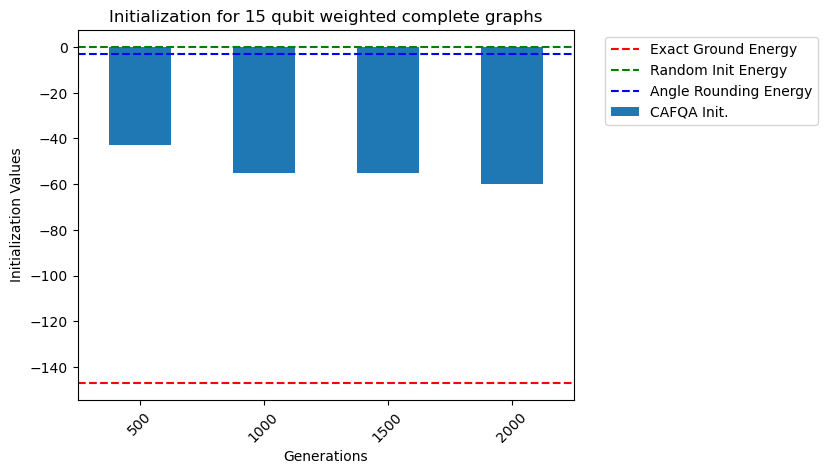

In [2]:
# create a dataframe with sample data
df = pd.DataFrame({
    'Generations': [500,1000,1500,2000],
    'CAFQA Init.': [-43,-55,-55,-60]
})

df.plot(x='Generations', y=['CAFQA Init.'], kind='bar')
exact_ground_energy = -147
random_init_energy = 0.09
angle_rounding_energy = -3

plt.axhline(y=exact_ground_energy, color='r', linestyle='--', label='Exact Ground Energy')
plt.axhline(y=random_init_energy, color='g', linestyle='--', label='Random Init Energy')
plt.axhline(y=angle_rounding_energy, color='b', linestyle='--', label='Angle Rounding Energy')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel('Generations')
plt.ylabel('Initialization Values')
plt.xticks(rotation=45)
plt.title('Initialization for 15 qubit weighted complete graphs')
plt.show()


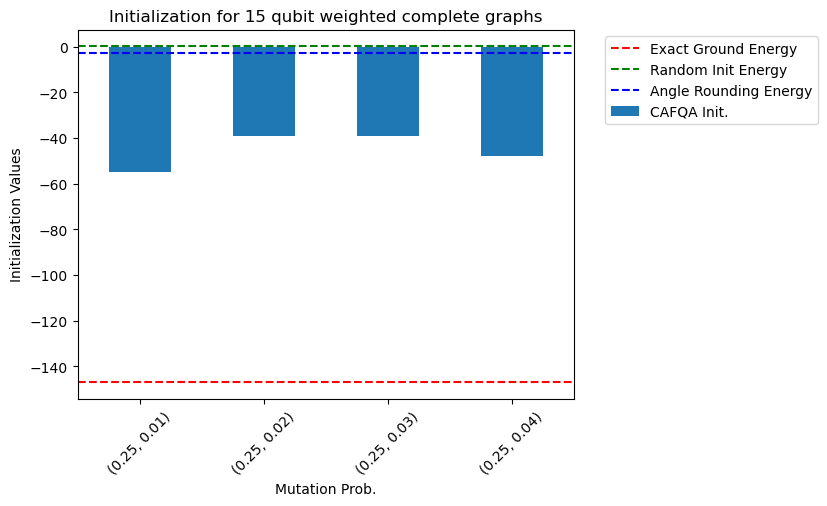

In [3]:
# create a dataframe with sample data
df = pd.DataFrame({
    'Mutation Prob.': [(0.25,0.01),(0.25,0.02),(0.25,0.03),(0.25,0.04)],
    'CAFQA Init.': [-55,-39,-39,-48]
})

df.plot(x='Mutation Prob.', y=['CAFQA Init.'], kind='bar')
exact_ground_energy = -147
random_init_energy = 0.09
angle_rounding_energy = -3

plt.axhline(y=exact_ground_energy, color='r', linestyle='--', label='Exact Ground Energy')
plt.axhline(y=random_init_energy, color='g', linestyle='--', label='Random Init Energy')
plt.axhline(y=angle_rounding_energy, color='b', linestyle='--', label='Angle Rounding Energy')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel('Mutation Prob.')
plt.ylabel('Initialization Values')
plt.xticks(rotation=45)
plt.title('Initialization for 15 qubit weighted complete graphs')
plt.show()


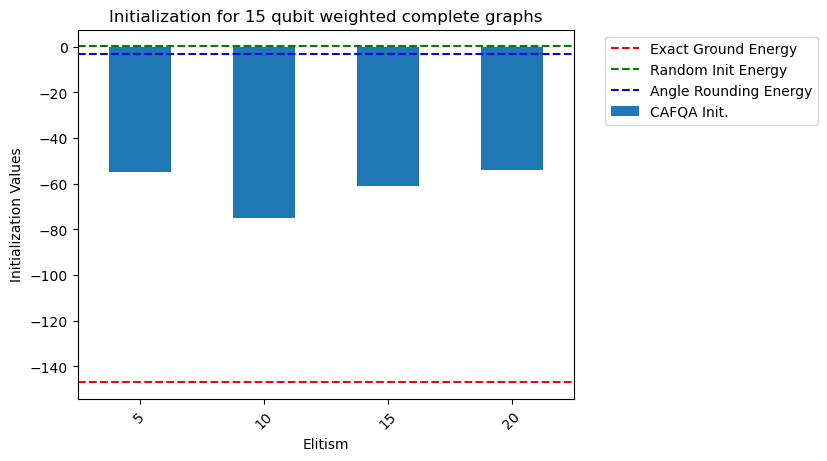

In [4]:
# create a dataframe with sample data
df = pd.DataFrame({
    'Elitism': [5,10,15,20],
    'CAFQA Init.': [-55,-75,-61,-54]
})

df.plot(x='Elitism', y=['CAFQA Init.'], kind='bar')
exact_ground_energy = -147
random_init_energy = 0.09
angle_rounding_energy = -3

plt.axhline(y=exact_ground_energy, color='r', linestyle='--', label='Exact Ground Energy')
plt.axhline(y=random_init_energy, color='g', linestyle='--', label='Random Init Energy')
plt.axhline(y=angle_rounding_energy, color='b', linestyle='--', label='Angle Rounding Energy')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel('Elitism')
plt.ylabel('Initialization Values')
plt.xticks(rotation=45)
plt.title('Initialization for 15 qubit weighted complete graphs')
plt.show()

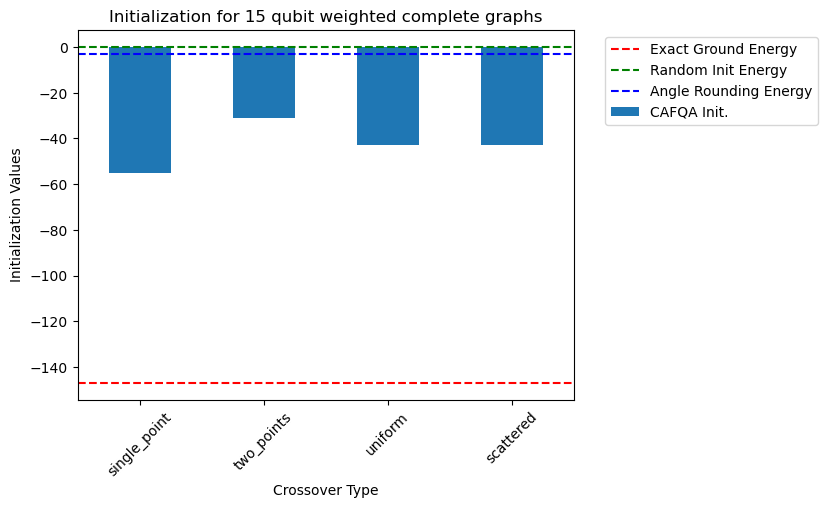

In [5]:
# create a dataframe with sample data
df = pd.DataFrame({
    'Elitism': ["single_point","two_points", "uniform", "scattered"],
    'CAFQA Init.': [-55,-31,-43,-43]
})

df.plot(x='Elitism', y=['CAFQA Init.'], kind='bar')
exact_ground_energy = -147
random_init_energy = 0.09
angle_rounding_energy = -3

plt.axhline(y=exact_ground_energy, color='r', linestyle='--', label='Exact Ground Energy')
plt.axhline(y=random_init_energy, color='g', linestyle='--', label='Random Init Energy')
plt.axhline(y=angle_rounding_energy, color='b', linestyle='--', label='Angle Rounding Energy')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel('Crossover Type')
plt.ylabel('Initialization Values')
plt.title('Initialization for 15 qubit weighted complete graphs')
plt.xticks(rotation=45)
plt.show()

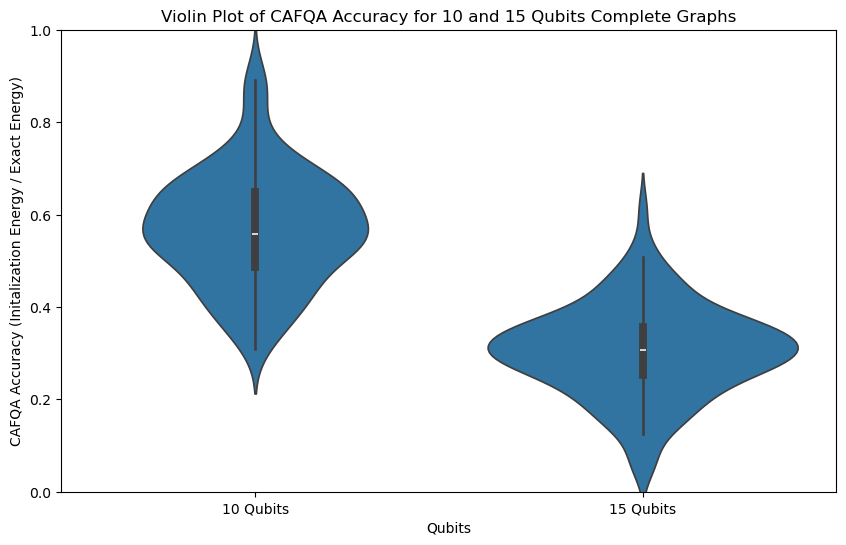

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def load_data(qubits, file_pattern, num_files):
    data_list = []
    for i in range(1, num_files + 1):
        file_path = file_pattern.format(i)
        data = np.load(file_path, allow_pickle=True).item()
        data['Qubits'] = f'{qubits} Qubits'
        data['CAFQA_Accuracy'] = data['CAFQA_initialization'] / data['Exact_solution']
        data['Random_Accuracy'] = data['Random_initialization'] / data['Exact_solution']
        data['Angle_Rounding_Accuracy'] = data['Angle_rounding'] / data['Exact_solution']
        data_list.append(data)
    return pd.DataFrame(data_list)

# Load data for 10 and 15 qubits
df_10 = load_data(10, '../np_data/10_qbs/energies_{}.npz.npy', 100)
df_15 = load_data(15, '../np_data/15_qbs/energies_{}.npy', 100)

# Combine the dataframes
df_combined = pd.concat([df_10, df_15])

# Plot the violin plot
plt.figure(figsize=(10, 6))
sns.violinplot(x='Qubits', y='CAFQA_Accuracy', data=df_combined)
plt.title('Violin Plot of CAFQA Accuracy for 10 and 15 Qubits Complete Graphs')
plt.ylabel('CAFQA Accuracy (Initalization Energy / Exact Energy)')
plt.ylim(0, 1)
plt.show()

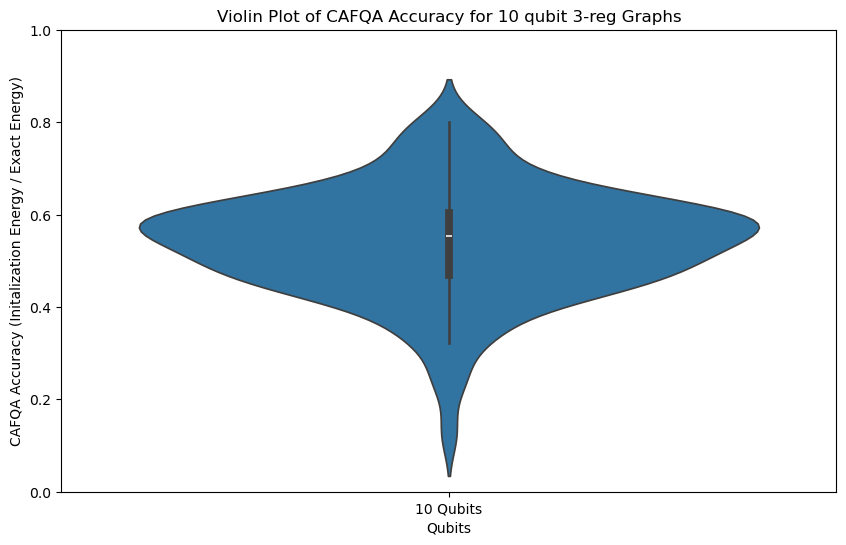

In [7]:


df_10_k_reg = load_data(10, '../np_data/10_qbs/k_reg_energies_{}.npy', 100)

plt.figure(figsize=(10, 6))
sns.violinplot(x='Qubits',y='CAFQA_Accuracy',data=df_10_k_reg)
plt.title('Violin Plot of CAFQA Accuracy for 10 qubit 3-reg Graphs')
plt.ylabel('CAFQA Accuracy (Initalization Energy / Exact Energy)')
plt.ylim(0, 1)
plt.show()


/tmp/ipykernel_2191475/137342996.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Structure of Graphs', y='CAFQA_Accuracy', data=df_combined_plot, split=False, palette=custom_palette)


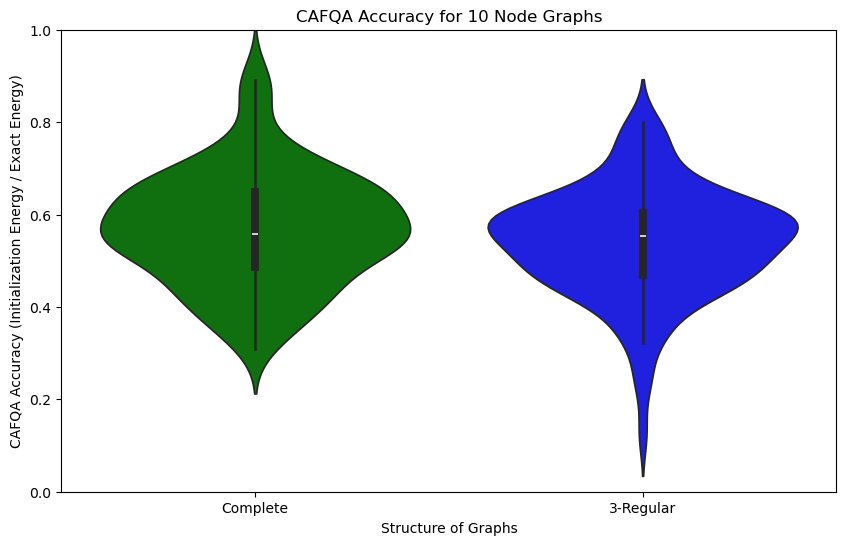

In [8]:
# Combine the datasets and add a new column to indicate the graph type
df_10['Structure of Graphs'] = 'Complete'
df_10_k_reg['Structure of Graphs'] = '3-Regular'

# Concatenate the two dataframes
df_combined_plot = pd.concat([df_10, df_10_k_reg])

# Define a custom color palette for the violins
custom_palette = {'Complete': 'green', '3-Regular': 'blue'}

# Plot the violin plot
plt.figure(figsize=(10, 6))
sns.violinplot(x='Structure of Graphs', y='CAFQA_Accuracy', data=df_combined_plot, split=False, palette=custom_palette)
plt.title('CAFQA Accuracy for 10 Node Graphs')
plt.ylabel('CAFQA Accuracy (Initialization Energy / Exact Energy)')
plt.ylim(0, 1)
# plt.savefig('../plots/Initial_Violin_Plots.png', dpi=800, bbox_inches='tight')
plt.show()



In [9]:
def load_sweep_data(qubits, file_pattern, num_files):
    data_list = []
    for i in range(1, num_files + 1):
        file_path = file_pattern.format(i)
        data = np.load(file_path, allow_pickle=True).item()
        data['Qubits'] = f'{qubits} Qubits'
        data['Init_CAFQA_Accuracy'] = data['CAFQA_initialization_energy'] / data['Exact_solution_energy']
        data['Init_Random_Accuracy'] = data['Random_initialization_energy'] / data['Exact_solution_energy']
        data['Init_Angle_Rounding_Accuracy'] = data['Angle_rounding_energy'] / data['Exact_solution_energy']

        data['Final_random_Accuracy'] = data['Final_random_energy'] / data['Exact_solution_energy']
        data['Final_Rounded_Accuracy'] = data['Final_Rounded_Angle_energy'] / data['Exact_solution_energy']
        data['Final_cafqa_Accuracy'] = data['Final_cafqa_energy'] / data['Exact_solution_energy']

        data['Init_CAFQA_to_Random_Energy_Ratio'] = data['CAFQA_initialization_energy'] / data['Random_initialization_energy']
        data['Final_CAFQA_to_Random_Energy_Ratio'] = abs(data['Final_cafqa_energy'] / (data['Final_random_energy'] - 1))

        data_list.append(data)
    return pd.DataFrame(data_list)


df_1_layer = load_sweep_data(15, '../np_data/rep_sweep/1_layers/results_{}.npy', 5)
df_2_layer = load_sweep_data(15, '../np_data/rep_sweep/2_layers/results_{}.npy', 5)
df_5_layer = load_sweep_data(15, '../np_data/rep_sweep/5_layers/results_{}.npy', 5)


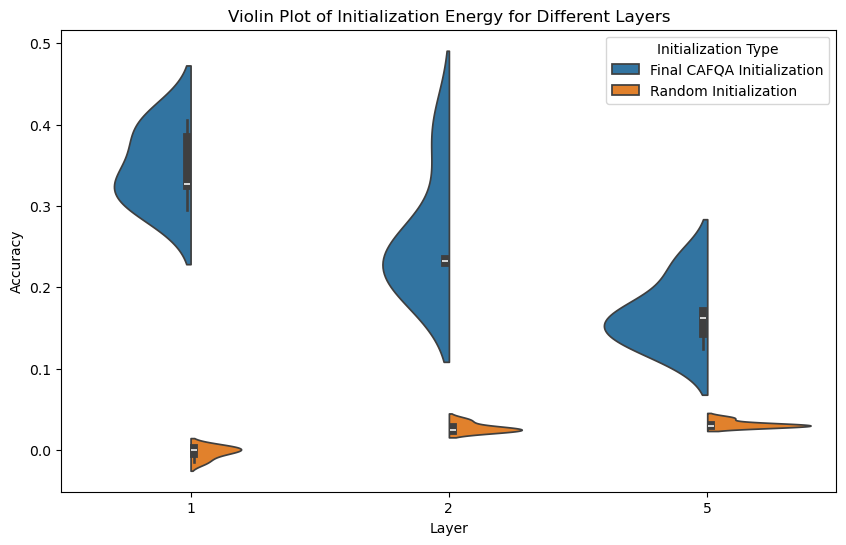

In [10]:
# Combine the dataframes for plotting
df_all_layers = pd.concat([
    df_1_layer[['Final_cafqa_Accuracy', 'Final_random_Accuracy', 'Qubits']].assign(Layer='1'),
    df_2_layer[['Final_cafqa_Accuracy', 'Final_random_Accuracy', 'Qubits']].assign(Layer='2'),
    df_5_layer[['Final_cafqa_Accuracy', 'Final_random_Accuracy', 'Qubits']].assign(Layer='5')
])

# Melt the dataframe for easier plotting
df_melted = df_all_layers.melt(id_vars=['Layer', 'Qubits'], value_vars=['Final_cafqa_Accuracy', 'Final_random_Accuracy'], var_name='Accuracy_Type', value_name='Accuracy')

# Plot the violin plot for both Final_cafqa_Accuracy and Final_random_Accuracy
plt.figure(figsize=(10, 6))
sns.violinplot(x='Layer', y='Accuracy', hue='Accuracy_Type', data=df_melted, split=True)

# Update the legend labels
handles, labels = plt.gca().get_legend_handles_labels()
updated_labels = ['Final CAFQA Initialization', 'Random Initialization']
plt.legend(handles, updated_labels, title='Initialization Type')

plt.title('Violin Plot of Initialization Energy for Different Layers')
plt.show()


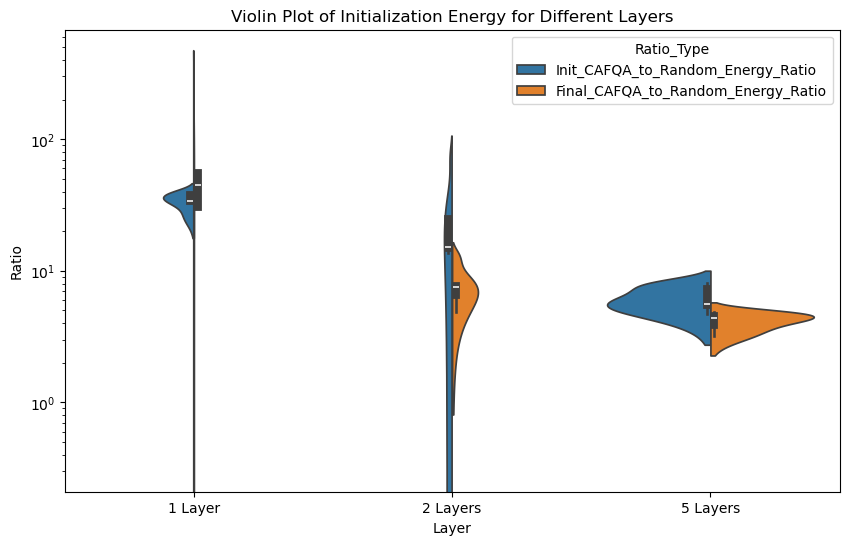

In [11]:
# Combine the dataframes for plotting

#NOTE: we didn't give enough generations for this data.

df_all_layers = pd.concat([
    df_1_layer[['Init_CAFQA_to_Random_Energy_Ratio', 'Final_CAFQA_to_Random_Energy_Ratio', 'Qubits']].assign(Layer='1 Layer'),
    df_2_layer[['Init_CAFQA_to_Random_Energy_Ratio', 'Final_CAFQA_to_Random_Energy_Ratio', 'Qubits']].assign(Layer='2 Layers'),
    df_5_layer[['Init_CAFQA_to_Random_Energy_Ratio', 'Final_CAFQA_to_Random_Energy_Ratio', 'Qubits']].assign(Layer='5 Layers')
])

# Melt the dataframe for easier plotting
df_melted = df_all_layers.melt(id_vars=['Layer', 'Qubits'], 
                               value_vars=['Init_CAFQA_to_Random_Energy_Ratio', 'Final_CAFQA_to_Random_Energy_Ratio'], 
                               var_name='Ratio_Type', value_name='Ratio')

# Plot the violin plot for both Final_cafqa_Accuracy and Final_random_Accuracy
plt.figure(figsize=(10, 6))
sns.violinplot(x='Layer', y='Ratio', hue='Ratio_Type', data=df_melted, split=True)
plt.title('Violin Plot of Initialization Energy for Different Layers')
plt.yscale('log')
plt.show()

In [12]:
df_1_layer = load_sweep_data(10, '../np_data/rep_sweep_2000_gens/1_layers/results_{}.npy', 5)
df_2_layer = load_sweep_data(10, '../np_data/rep_sweep_2000_gens/2_layers/results_{}.npy', 5)
df_5_layer = load_sweep_data(10, '../np_data/rep_sweep_2000_gens/5_layers/results_{}.npy', 5)

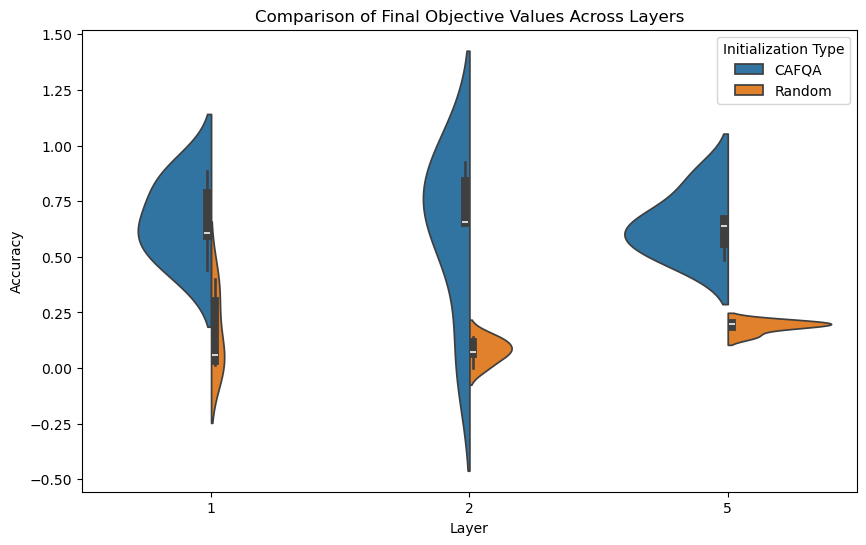

In [13]:
# Combine the dataframes for plotting
df_all_layers = pd.concat([
    df_1_layer[['Final_cafqa_Accuracy', 'Final_random_Accuracy', 'Qubits']].assign(Layer='1'),
    df_2_layer[['Final_cafqa_Accuracy', 'Final_random_Accuracy', 'Qubits']].assign(Layer='2'),
    df_5_layer[['Final_cafqa_Accuracy', 'Final_random_Accuracy', 'Qubits']].assign(Layer='5')
])

# Melt the dataframe for easier plotting
df_melted = df_all_layers.melt(id_vars=['Layer', 'Qubits'], value_vars=['Final_cafqa_Accuracy', 'Final_random_Accuracy'], var_name='Accuracy_Type', value_name='Accuracy')

# Plot the violin plot for both Final_cafqa_Accuracy and Final_random_Accuracy
plt.figure(figsize=(10, 6))
sns.violinplot(x='Layer', y='Accuracy', hue='Accuracy_Type', data=df_melted, split=True)

# Update the legend labels
handles, labels = plt.gca().get_legend_handles_labels()
updated_labels = ['CAFQA', 'Random']
plt.legend(handles, updated_labels, title='Initialization Type')

plt.title('Comparison of Final Objective Values Across Layers')
# plt.savefig('../plots/Final_Obj_Vals.png', dpi=800, bbox_inches='tight')
plt.show()

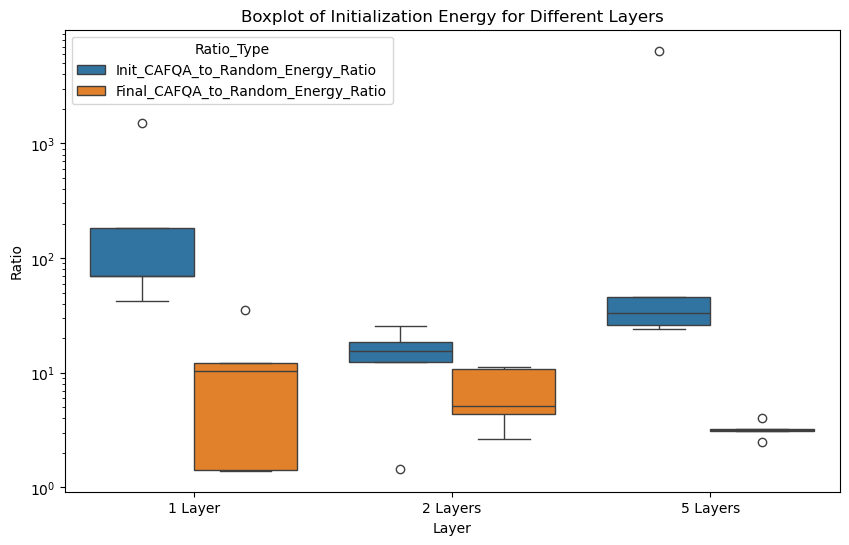

In [14]:
# Combine the dataframes for plotting
df_all_layers = pd.concat([
    df_1_layer[['Init_CAFQA_to_Random_Energy_Ratio', 'Final_CAFQA_to_Random_Energy_Ratio']].abs().assign(Layer='1 Layer'),
    df_2_layer[['Init_CAFQA_to_Random_Energy_Ratio', 'Final_CAFQA_to_Random_Energy_Ratio']].abs().assign(Layer='2 Layers'),
    df_5_layer[['Init_CAFQA_to_Random_Energy_Ratio', 'Final_CAFQA_to_Random_Energy_Ratio']].abs().assign(Layer='5 Layers')
])

# Melt the dataframe for easier plotting
df_melted = df_all_layers.melt(id_vars=['Layer'], 
                               value_vars=['Init_CAFQA_to_Random_Energy_Ratio', 'Final_CAFQA_to_Random_Energy_Ratio'], 
                               var_name='Ratio_Type', value_name='Ratio')

# Plot the violin plot for both Final_cafqa_Accuracy and Final_random_Accuracy
# plt.figure(figsize=(10, 6))
# sns.violinplot(x='Layer', y='Ratio', hue='Ratio_Type', data=df_melted, split=True)
# plt.title('Violin Plot of Initialization Energy for Different Layers')
# plt.yscale('log')
# plt.show()


# Plot the boxplot for both Final_cafqa_Accuracy and Final_random_Accuracy
plt.figure(figsize=(10, 6))
sns.boxplot(x='Layer', y='Ratio', hue='Ratio_Type', data=df_melted)
plt.title('Boxplot of Initialization Energy for Different Layers')
plt.yscale('log')
plt.show()


In [15]:
df_2_layer[['Exact_solution_energy', 'CAFQA_initialization_energy','Final_random_energy','Final_cafqa_energy','Random_obj_values','CAFQA_obj_values']]

,Exact_solution_energy,CAFQA_initialization_energy,Final_random_energy,Final_cafqa_energy,Random_obj_values,CAFQA_obj_values
0,-75.0,-48.0,-0.147949,-3.039062,"[26.03125, 21.6064453125, 21.99853515625, 21.3...","[-0.69677734375, -0.53759765625, 1.033203125, ..."
1,-91.0,-76.0,-5.755371,-76.549316,NaN,NaN
2,-90.0,-59.0,-12.630371,-59.260254,NaN,NaN
3,-83.0,-54.0,-9.553223,-54.121582,NaN,NaN
4,-79.0,-73.0,-5.747559,-73.013672,NaN,NaN


In [16]:
df_1_layer[['Init_CAFQA_to_Random_Energy_Ratio', 'Final_CAFQA_to_Random_Energy_Ratio']].abs().mean(),df_2_layer[['Init_CAFQA_to_Random_Energy_Ratio', 'Final_CAFQA_to_Random_Energy_Ratio']].abs().mean(),df_5_layer[['Init_CAFQA_to_Random_Energy_Ratio', 'Final_CAFQA_to_Random_Energy_Ratio']].abs().mean()

(Init_CAFQA_to_Random_Energy_Ratio     376.312432
 Final_CAFQA_to_Random_Energy_Ratio     12.118759
 dtype: float64,
 Init_CAFQA_to_Random_Energy_Ratio     14.786010
 Final_CAFQA_to_Random_Energy_Ratio     6.855173
 dtype: float64,
 Init_CAFQA_to_Random_Energy_Ratio     1313.080330
 Final_CAFQA_to_Random_Energy_Ratio       3.190855
 dtype: float64)

In [17]:
#NOTE: I believe the above data were for early experiments 
#       with no actual improvement in optimization for any points 

# Knapsack Problems

In [18]:
def load_knapsack_data(qubits, file_pattern, num_files):
    data_list = []
    for i in range(1, num_files + 1):
        file_path = file_pattern.format(i)
        data = np.load(file_path, allow_pickle=True).item()
        data['Qubits'] = f'{qubits} Qubits'
        data['Init_CAFQA_Accuracy'] = data['CAFQA_energy'] / data['Exact_solution_energy']
        data['Init_Random_Accuracy'] = data['Min_random_energy'] / data['Exact_solution_energy']
        # data['Init_Angle_Rounding_Accuracy'] = data['Angle_rounding_energy'] / data['Exact_solution_energy']

        # data['Final_random_Accuracy'] = data['Final_random_energy'] / data['Exact_solution_energy']
        # data['Final_Rounded_Accuracy'] = data['Final_Rounded_Angle_energy'] / data['Exact_solution_energy']
        # data['Final_cafqa_Accuracy'] = data['Final_cafqa_energy'] / data['Exact_solution_energy']

        # data['Init_CAFQA_to_Random_Energy_Ratio'] = data['CAFQA_initialization_energy'] / data['Random_initialization_energy']
        # data['Final_CAFQA_to_Random_Energy_Ratio'] = abs(data['Final_cafqa_energy'] / (data['Final_random_energy'] - 1))

        data_list.append(data)
    return pd.DataFrame(data_list)



knapsack_df = load_knapsack_data(15, '../np_data/knapsack/16_qubits/results_{}.npy', 10)

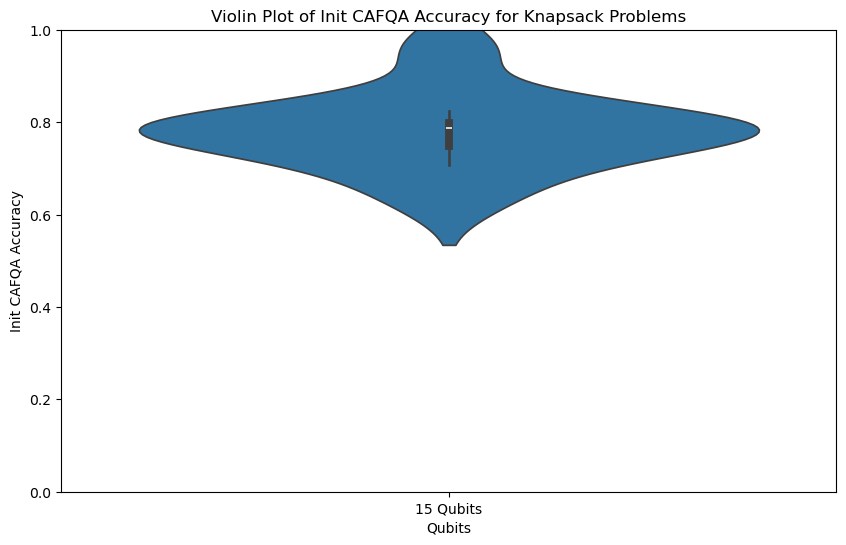

In [19]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='Qubits', y='Init_CAFQA_Accuracy', data=knapsack_df)
plt.title('Violin Plot of Init CAFQA Accuracy for Knapsack Problems')
plt.ylabel('Init CAFQA Accuracy')
plt.ylim(0, 1)
plt.show()

In [20]:
max_init_cafqa_accuracy = knapsack_df['Init_CAFQA_Accuracy'].max()
print(max_init_cafqa_accuracy)

0.9567190933271655


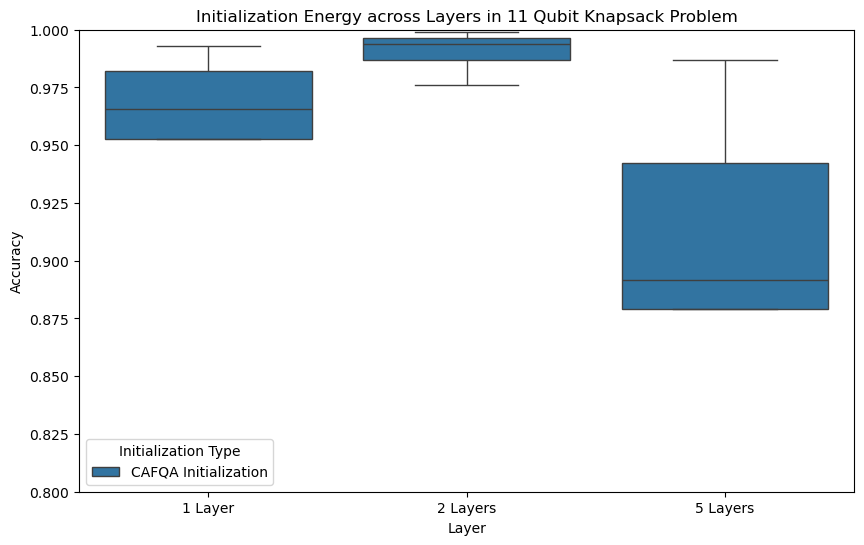

In [21]:
#Parameter sweep for knapsack 

# Manually create dictionaries for each layer
data_1_layer = {
    'Layer': ['1 Layer', '1 Layer', '1 Layer', '1 Layer', '1 Layer'],
    'CAFQA Accuracy': [-25417.5/-26316.5, 
                       -7744.0/-7886.0, 
                       -19624.0/-19764.0, 
                       -10628.0/-11154.5, 
                       -15750.0/-23761.5],
}

data_2_layer = {
    'Layer': ['2 Layers', '2 Layers', '2 Layers', '2 Layers', '2 Layers'],
    'CAFQA Accuracy': [-26292.0/-26316.5, 
                        -7781.0/-7886.0, 
                        -19287.5/-19764.0, 
                        -11112.5/-11154.5, 
                        -23614.5/-23761.5],
}

data_5_layer = {
    'Layer': ['5 Layers', '5 Layers', '5 Layers', '5 Layers', '5 Layers'],
    'CAFQA Accuracy': [-19805.5/-26316.5,
                       -7781.0/-7886.0, 
                       -18624.5/-19764.0,
                         -9944.0/-11154.5, 
                         -20887.0/-23761.5],
}

# Combine the dictionaries into a single DataFrame for plotting
combined_data = {
    'Layer': data_1_layer['Layer'] + data_2_layer['Layer'] + data_5_layer['Layer'],
    'CAFQA Accuracy': data_1_layer['CAFQA Accuracy'] + data_2_layer['CAFQA Accuracy'] + data_5_layer['CAFQA Accuracy'],
    # 'Random Accuracy': data_1_layer['Random Accuracy'] + data_2_layer['Random Accuracy'] + data_5_layer['Random Accuracy']
}

# Convert the combined data into a DataFrame
df_combined = pd.DataFrame(combined_data)

# Plot the violin plot for both CAFQA Accuracy and Random Accuracy
df_melted = df_combined.melt(id_vars=['Layer'], value_vars=['CAFQA Accuracy'], 
                             var_name='Accuracy_Type', value_name='Accuracy')

# plt.figure(figsize=(10, 6))
# sns.violinplot(x='Layer', y='Accuracy', hue='Accuracy_Type', data=df_melted, split=False,cut=0)
# plt.title('Violin Plot of Initialization Energy for Different Layers in Knapsack')
# plt.show()


# Plot the boxplot for CAFQA Accuracy
plt.figure(figsize=(10, 6))
plt.ylim(0.8, 1.0)
sns.boxplot(x='Layer', y='Accuracy', hue='Accuracy_Type', data=df_melted)
plt.title('Initialization Energy across Layers in 11 Qubit Knapsack Problem')

# Update the legend labels
handles, labels = plt.gca().get_legend_handles_labels()
updated_labels = ['CAFQA Initialization']
plt.legend(handles, updated_labels, title='Initialization Type')
# plt.savefig('../plots/Knapsack_Initial_Box.png', dpi=800, bbox_inches='tight')

plt.show()

In [22]:

single_data = np.load( '../np_data/knapsack/rep_sweep/11_qubits/results_single_1.npy',allow_pickle=True).item()

final_data = []
final_data.append({
    'CAFQA_initial_energy': single_data['CAFQA_initial_energy'],
    'Exact_solution_energy': single_data['Exact_solution_energy'],
    'Min_initial_random_energy': single_data['Min_initial_random_energy'],
    'Final_cafqa_energy': single_data['Final_cafqa_energy'],
    'Final_random_energy': single_data['Final_random_energy'],
    "CAFQA_objective_values" : single_data['CAFQA_objective_values'],
    'Random_objective_values' : single_data['Random_objective_values']

})

final_df = pd.DataFrame(final_data)
final_df

,CAFQA_initial_energy,Exact_solution_energy,Min_initial_random_energy,Final_cafqa_energy,Final_random_energy,CAFQA_objective_values,Random_objective_values
0,-25125.0,-26316.5,3586.04150390625,-25186.435547,-10914.834717,"[-25103.1689453125, -24697.391845703125, -2444...","[5123.14990234375, 4199.66650390625, 4718.4218..."


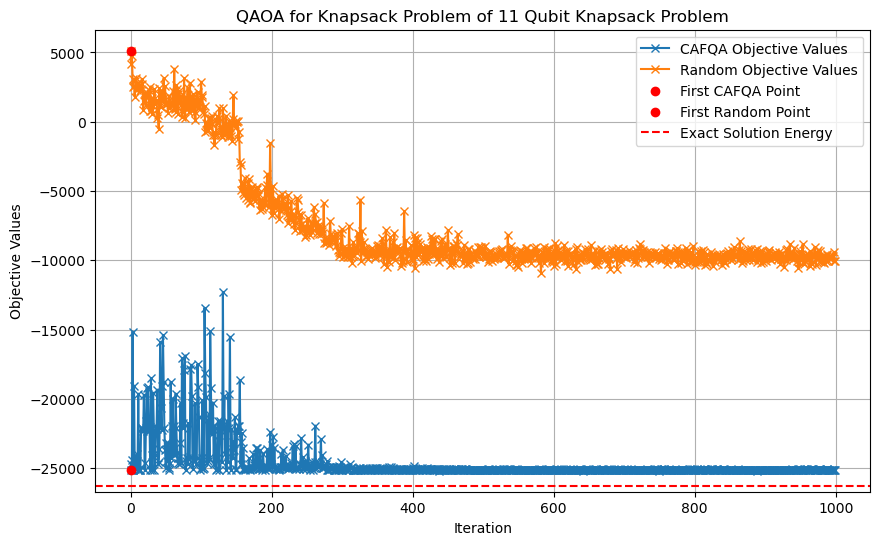

In [23]:
# Extract the values from the dictionary
cafqa_values = single_data['CAFQA_objective_values']
random_values = single_data['Random_objective_values']

# Create a range for the x-axis (indices)
indices = range(len(cafqa_values))

# Plot the values
plt.figure(figsize=(10, 6))
plt.plot(indices, cafqa_values, label='CAFQA Objective Values', marker='x')
plt.plot(indices, random_values, label='Random Objective Values', marker='x')

# Highlight the first point in red
plt.scatter(0, cafqa_values[0], color='red', label='First CAFQA Point', zorder=5)
plt.scatter(0, random_values[0], color='red', label='First Random Point', zorder=5)

# Plot the Exact_solution_energy as a dotted horizontal line
exact_solution_energy = single_data['Exact_solution_energy']
plt.axhline(y=exact_solution_energy, color='r', linestyle='--', label='Exact Solution Energy')

# Add labels, title, legend, and grid
plt.xlabel('Iteration')
plt.ylabel('Objective Values')
plt.title('QAOA for Knapsack Problem of 11 Qubit Knapsack Problem')
plt.legend()
plt.grid()
# plt.savefig('../plots/Knapsack_11_qb_QAOA.png', dpi=800, bbox_inches='tight')
plt.show()


In [24]:
teague_vanilla_data = np.load( '../np_data/teague_data/8_qubits/vanilla_results.npy',allow_pickle=True).item()


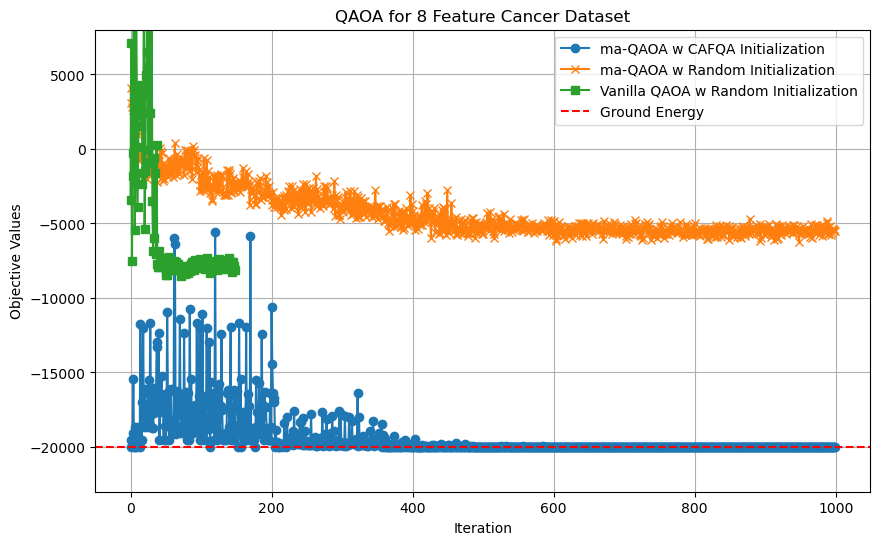

In [25]:
#Teague Data (8 qubits) 

teague_data = np.load( '../np_data/teague_data/8_qubits/results.npy',allow_pickle=True).item()
teague_df = pd.DataFrame({
    'CAFQA Final Energy': [teague_data['cafqa_fin_energy']],
    'Random Result Energy': [teague_data['random_result_energy']],
    'CAFQA Iteration Values': [teague_data['cafqa_iteration_vals']],
    'Random Iteration Values': [teague_data['random_iteration_vals']]
})
teague_vanilla_data = np.load( '../np_data/teague_data/8_qubits/vanilla_results.npy',allow_pickle=True).item()
teague_vanilla_df = pd.DataFrame({
    'Vanilla Final Energy': [teague_vanilla_data['vanilla_fin_energy'].fun],
    'Vanilla Iteration Values': [teague_vanilla_data['vanilla_iteration_values']]
})

# Extract the iteration values
cafqa_iteration_vals = teague_data['cafqa_iteration_vals']
random_iteration_vals = teague_data['random_iteration_vals']
vanilla_iteration_vals = teague_vanilla_data['vanilla_iteration_values']

# Create a range for the x-axis (indices)
indices = range(len(cafqa_iteration_vals))

# Plot the iteration values
plt.figure(figsize=(10, 6))
plt.plot(indices, cafqa_iteration_vals, label='ma-QAOA w CAFQA Initialization', marker='o')
plt.plot(indices, random_iteration_vals, label='ma-QAOA w Random Initialization', marker='x')
plt.plot(range(len(vanilla_iteration_vals)), vanilla_iteration_vals, label='Vanilla QAOA w Random Initialization', marker='s')
plt.axhline(y=-20006.45, color='r', linestyle='--', label='Ground Energy')

# Add labels, title, legend, and grid
plt.xlabel('Iteration')
plt.ylabel('Objective Values')
plt.title('QAOA for 8 Feature Cancer Dataset')
plt.legend()
plt.grid()
plt.ylim(-23000, 8000)
# plt.savefig('../plots/Teague_data_8_qubits_initialization.png', dpi=800, bbox_inches='tight')
plt.show()

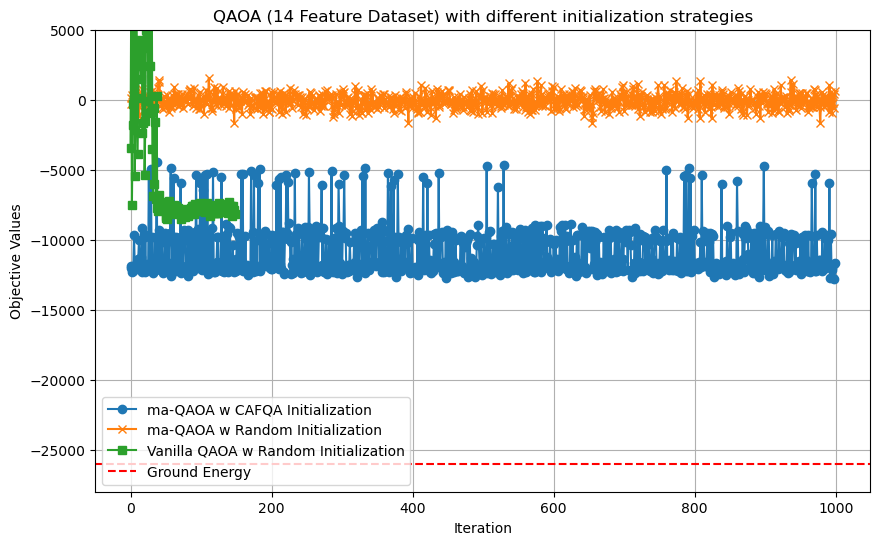

In [26]:
#Teague Data (14 qubits) 

teague_data = np.load( '../np_data/teague_data/14_qubits/results.npy',allow_pickle=True).item()
teague_df = pd.DataFrame({
    'CAFQA Final Energy': [teague_data['cafqa_fin_energy']],
    'Random Result Energy': [teague_data['random_result_energy']],
    'CAFQA Iteration Values': [teague_data['cafqa_iteration_vals']],
    'Random Iteration Values': [teague_data['random_iteration_vals']]
})
teague_vanilla_data = np.load( '../np_data/teague_data/8_qubits/vanilla_results.npy',allow_pickle=True).item()
teague_vanilla_df = pd.DataFrame({
    'Vanilla Final Energy': [teague_vanilla_data['vanilla_fin_energy'].fun],
    'Vanilla Iteration Values': [teague_vanilla_data['vanilla_iteration_values']]
})

# Extract the iteration values
cafqa_iteration_vals = teague_data['cafqa_iteration_vals']
random_iteration_vals = teague_data['random_iteration_vals']
vanilla_iteration_vals = teague_vanilla_data['vanilla_iteration_values']

# Create a range for the x-axis (indices)
indices = range(len(cafqa_iteration_vals))

# Plot the iteration values
plt.figure(figsize=(10, 6))
plt.plot(indices, cafqa_iteration_vals, label='ma-QAOA w CAFQA Initialization', marker='o')
plt.plot(indices, random_iteration_vals, label='ma-QAOA w Random Initialization', marker='x')
plt.plot(range(len(vanilla_iteration_vals)), vanilla_iteration_vals, label='Vanilla QAOA w Random Initialization', marker='s')
plt.axhline(y=-26014.18, color='r', linestyle='--', label='Ground Energy')

# Add labels, title, legend, and grid
plt.xlabel('Iteration')
plt.ylabel('Objective Values')
plt.title('QAOA (14 Feature Dataset) with different initialization strategies')
plt.legend()
plt.grid()
plt.ylim(-28000, 5000)
# plt.savefig('../plots/Teague_data_14_qubits_initialization.png', dpi=800, bbox_inches='tight')
plt.show()


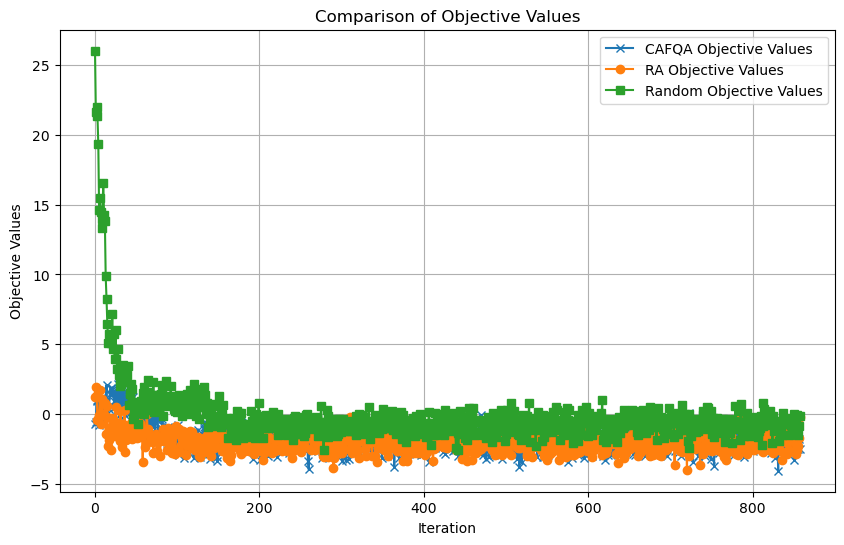

In [27]:
# noisy plot 10 qb using device backend 

noisy_data = np.load( '../np_data/rep_sweep_2000_gens/2_layers/results_1.npy',allow_pickle=True).item()

noisy_df = pd.DataFrame({
    'CAFQA_initial_energy': [noisy_data['CAFQA_initialization_energy']],
    'Exact_solution_energy': [noisy_data['Exact_solution_energy']],
    'Random_initial_energy': [noisy_data['Random_initialization_energy']],
    'Final_cafqa_energy': [noisy_data['Final_cafqa_energy']],
    'Final_random_energy': [noisy_data['Final_random_energy']],
    'CAFQA_objective_values': [noisy_data['CAFQA_obj_values']],
    'RA_objective_values': [noisy_data['RA_obj_values']],
    'Random_objective_values': [noisy_data['Random_obj_values']]
})

# Extract the values from the dictionary
cafqa_values = noisy_data['CAFQA_obj_values']
ra_values = noisy_data['RA_obj_values']
random_values = noisy_data['Random_obj_values']

# Create a range for the x-axis (indices)
indices = range(len(cafqa_values))

# Determine the minimum length among the three arrays
min_length = min(len(cafqa_values), len(ra_values), len(random_values))

# Trim the arrays to the minimum length
cafqa_values_trimmed = cafqa_values[:min_length]
ra_values_trimmed = ra_values[:min_length]
random_values_trimmed = random_values[:min_length]
indices_trimmed = range(min_length)

# Plot the values
plt.figure(figsize=(10, 6))
plt.plot(indices_trimmed, cafqa_values_trimmed, label='CAFQA Objective Values', marker='x')
plt.plot(indices_trimmed, ra_values_trimmed, label='RA Objective Values', marker='o')
plt.plot(indices_trimmed, random_values_trimmed, label='Random Objective Values', marker='s')

# # Plot a horizontal line for the exact solution energy
# exact_solution_energy = noisy_data['Exact_solution_energy']
# plt.axhline(y=exact_solution_energy, color='r', linestyle='--', label='Exact Solution Energy')

# Add labels, title, legend, and grid
plt.xlabel('Iteration')
plt.ylabel('Objective Values')
plt.title('Comparison of Objective Values')
plt.legend()
plt.grid()
plt.show()

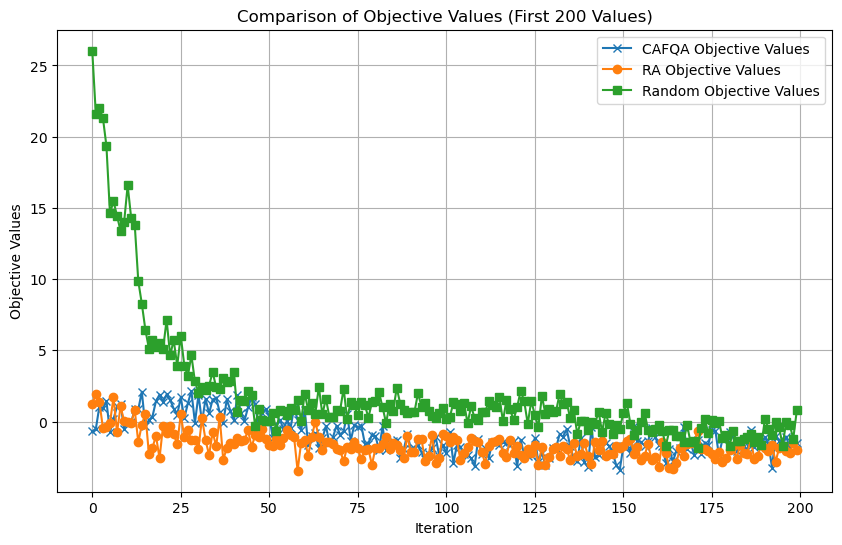

In [28]:
# Zoomed in 

# Limit the data to the first 200 values
cafqa_values_limited = cafqa_values_trimmed[:200]
ra_values_limited = ra_values_trimmed[:200]
random_values_limited = random_values_trimmed[:200]
indices_limited = range(len(cafqa_values_limited))

# Plot the limited values

plt.figure(figsize=(10, 6))
plt.plot(indices_limited, cafqa_values_limited, label='CAFQA Objective Values', marker='x')
plt.plot(indices_limited, ra_values_limited, label='RA Objective Values', marker='o')
plt.plot(indices_limited, random_values_limited, label='Random Objective Values', marker='s')

# Add labels, title, legend, and grid
plt.xlabel('Iteration')
plt.ylabel('Objective Values')
plt.title('Comparison of Objective Values (First 200 Values)')
plt.legend()
plt.grid()
plt.show()

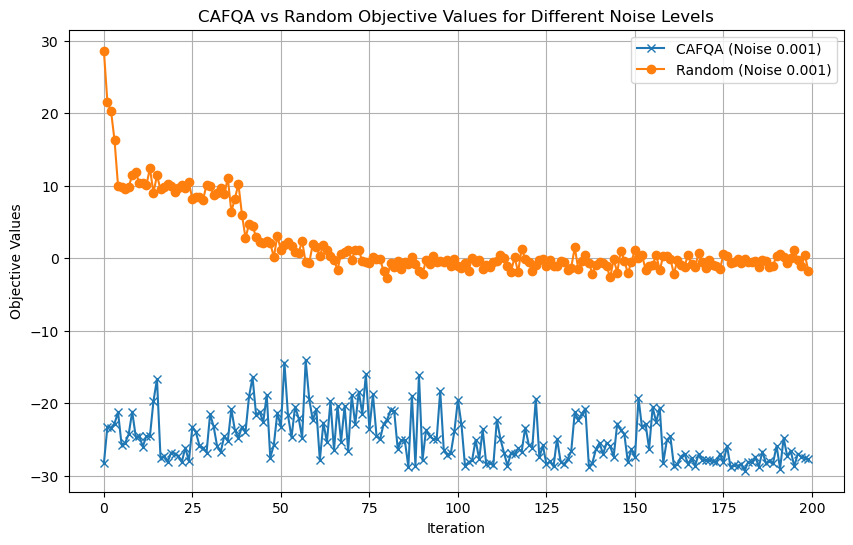

In [29]:
# Noise Sweep 

noisy_sweep_data = np.load( '../np_data/rep_sweep_2000_gens/2_layers/n-cafqa_single_noisy_results_1.npy',allow_pickle=True).item()
# Define the noise levels
noise_levels = [1e-3]

# Initialize the plot
plt.figure(figsize=(10, 6))

# Loop through each noise level and plot the results
for noise_level in noise_levels:
    cafqa_values = noisy_sweep_data[noise_level]['CAFQA_obj_values']
    random_values = noisy_sweep_data[noise_level]['Random_obj_values']
    indices = range(len(cafqa_values))
    
    plt.plot(indices, cafqa_values, label=f'CAFQA (Noise {noise_level})', marker='x')
    plt.plot(indices, random_values, label=f'Random (Noise {noise_level})', marker='o')

# Add labels, title, legend, and grid
plt.xlabel('Iteration')
plt.ylabel('Objective Values')
plt.title('CAFQA vs Random Objective Values for Different Noise Levels')
plt.legend()
plt.grid()
plt.show()

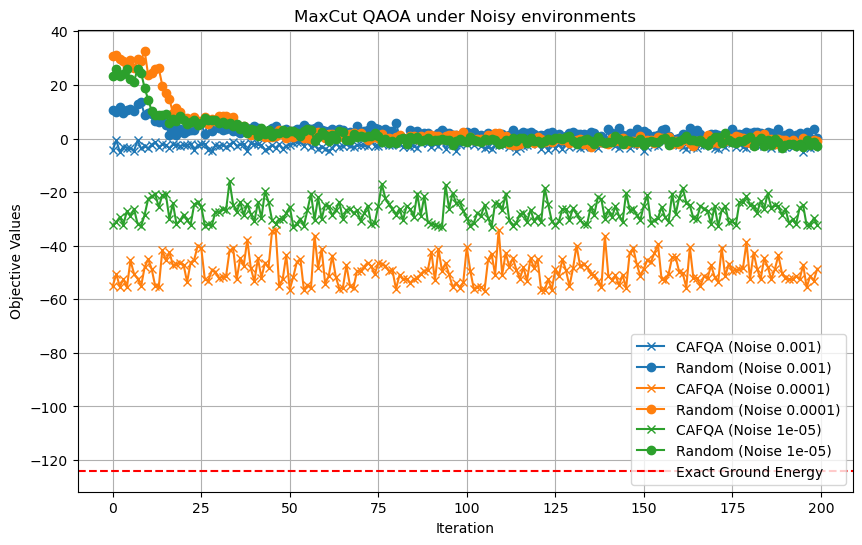

In [30]:
# Noise Sweep but the graphs were all different  

# single_noisy = np.load('../np_data/rep_sweep_2000_gens/2_layers/n-cafqa_single_noisy_results_1.npy', allow_pickle=True).item()

single_noisy = np.load('../np_data/rep_sweep_2000_gens/2_layers/1e-3_new_n-cafqa_single_noisy_results_1.npy', allow_pickle=True).item()
new_single_data = np.load('../np_data/rep_sweep_2000_gens/2_layers/new_n-cafqa_single_noisy_results_1.npy', allow_pickle=True).item()
lowest_single_data = np.load('../np_data/rep_sweep_2000_gens/2_layers/1e-5_new_n-cafqa_single_noisy_results_1.npy', allow_pickle=True).item()

# Merge all three dictionaries
single_noisy.update(new_single_data)
single_noisy.update(lowest_single_data)

noise_levels = [1e-3,1e-4,1e-5]

# Initialize the plot
plt.figure(figsize=(10, 6))

better_palette = sns.color_palette(["#1f77b4", "#ff7f0e", "#2ca02c"])

# Loop through each noise level and plot the results
for i,noise_level in enumerate(noise_levels):
    cafqa_values = single_noisy[noise_level]['CAFQA_obj_values']
    random_values = single_noisy[noise_level]['Random_obj_values']
    indices = range(len(cafqa_values))

    
    
    plt.plot(np.arange(len(cafqa_values)), cafqa_values, label=f'CAFQA (Noise {noise_level})', marker='x', color = better_palette[i])
    plt.plot(np.arange(len(random_values)), random_values, label=f'Random (Noise {noise_level})', marker='o' , color=better_palette[i])

exact_ground_e = single_noisy[1e-3]['exact_energy']
# Plot the exact ground energy as a horizontal line
plt.axhline(y=exact_ground_e, color='r', linestyle='--', label='Exact Ground Energy')

# Add labels, title, legend, and grid
plt.xlabel('Iteration')
plt.ylabel('Objective Values')
plt.title('MaxCut QAOA under Noisy environments')
plt.legend(bbox_to_anchor=(1, 0), loc='lower right')
plt.grid()
# plt.savefig('../plots/Noisy_Plots.png', dpi=800, bbox_inches='tight')
plt.show()

# Results with Vanilla QAOA

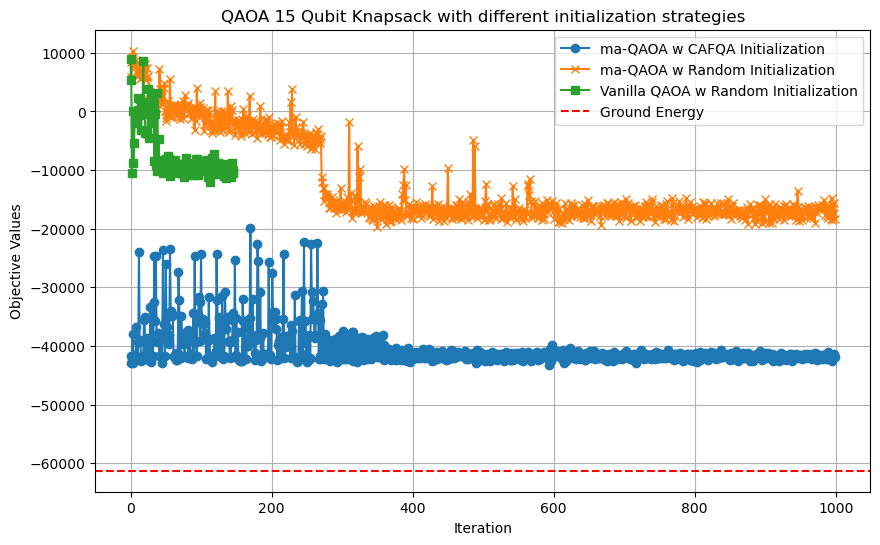

In [31]:
#Teague Data (14 qubits) 

vanilla_knapsack = np.load( '../np_data/knapsack/rep_sweep/15_qubits/results_single1.npy',allow_pickle=True).item()
vanilla_df = pd.DataFrame({
    'CAFQA Iteration Values': [vanilla_knapsack['CAFQA_objective_values']],
    'Random Iteration Values': [vanilla_knapsack['Random_objective_values']],
    'Vanilla QAOA iteration vals': [vanilla_knapsack['Vanilla_QAOA_objective_values']]
})

# Extract the iteration values
cafqa_iteration_vals = vanilla_knapsack['CAFQA_objective_values']
random_iteration_vals = vanilla_knapsack['Random_objective_values']
vanilla_iteration_vals = vanilla_knapsack['Vanilla_QAOA_objective_values']
exact_energy  = vanilla_knapsack['Exact_solution_energy']

# Create a range for the x-axis (indices)
indices = range(len(cafqa_iteration_vals))

# Plot the iteration values
plt.figure(figsize=(10, 6))
plt.plot(indices, cafqa_iteration_vals, label='ma-QAOA w CAFQA Initialization', marker='o')
plt.plot(indices, random_iteration_vals, label='ma-QAOA w Random Initialization', marker='x')
plt.plot(range(len(vanilla_iteration_vals)), vanilla_iteration_vals, label='Vanilla QAOA w Random Initialization', marker='s')
plt.axhline(y=exact_energy, color='r', linestyle='--', label='Ground Energy')

# Add labels, title, legend, and grid
plt.xlabel('Iteration')
plt.ylabel('Objective Values')
plt.title('QAOA 15 Qubit Knapsack with different initialization strategies')
plt.legend()
plt.grid()
# plt.savefig('../plots/Teague_Dataset_Vanilla.png', dpi=800, bbox_inches='tight')
plt.show()


In [32]:
vanilla_knapsack

{'CAFQA_initial_energy': np.float64(-42013.5),
 'Exact_solution_energy': np.float64(-61276.5),
 'Min_initial_random_energy': array(4810.83520508),
 'Final_cafqa_energy': np.float64(-43208.4404296875),
 'Final_random_energy': np.float64(-19710.00341796875),
 'Vanilla_QAOA_energy': np.float64(-10471.1279296875),
 'Random_objective_values': [array(8383.49365234),
  array(5813.56958008),
  array(9195.54760742),
  array(8772.41259766),
  array(10349.21435547),
  array(7831.59643555),
  array(7565.14501953),
  array(7964.11791992),
  array(8795.7019043),
  array(6590.86035156),
  array(6387.81469727),
  array(5966.61254883),
  array(7007.09814453),
  array(7837.36303711),
  array(5455.22241211),
  array(6450.94628906),
  array(6929.92358398),
  array(5914.69848633),
  array(5947.64038086),
  array(6842.49829102),
  array(7333.20581055),
  array(8009.21337891),
  array(5433.20678711),
  array(7386.2121582),
  array(5950.49926758),
  array(5980.92089844),
  array(3105.36157227),
  array(1662.5

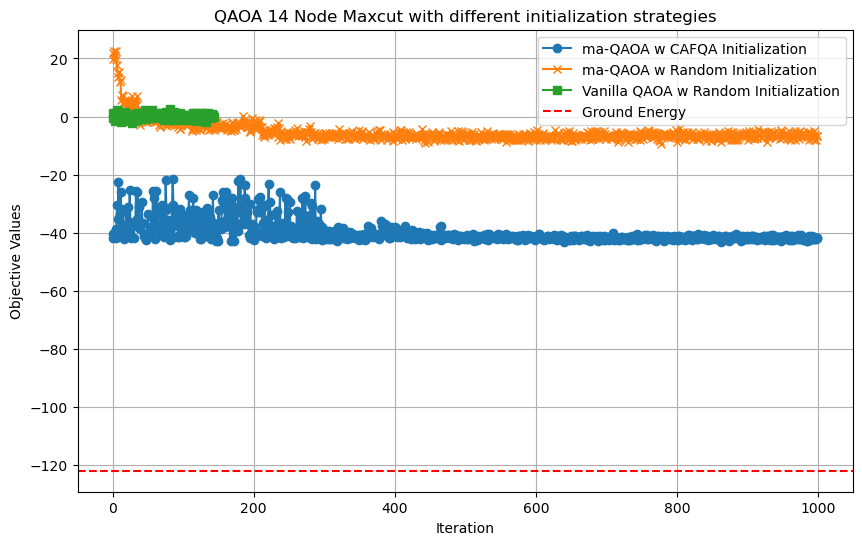

In [33]:

vanilla_maxcut = np.load( '../np_data/rep_sweep_2000_gens/2_layers/single_results_1.npy',allow_pickle=True).item()

# Extract the iteration values
cafqa_iteration_vals = vanilla_maxcut['CAFQA_obj_values']
random_iteration_vals = vanilla_maxcut['Random_obj_values']
vanilla_iteration_vals = vanilla_maxcut['Vanilla_QAOA_values']
exact_energy  = vanilla_maxcut['Exact_solution_energy']


# Create a range for the x-axis (indices)
indices = range(len(cafqa_iteration_vals))

# Plot the iteration values
plt.figure(figsize=(10, 6))
plt.plot(indices, cafqa_iteration_vals, label='ma-QAOA w CAFQA Initialization', marker='o')
plt.plot(indices, random_iteration_vals, label='ma-QAOA w Random Initialization', marker='x')
plt.plot(range(len(vanilla_iteration_vals)), vanilla_iteration_vals, label='Vanilla QAOA w Random Initialization', marker='s')
plt.axhline(y=exact_energy, color='r', linestyle='--', label='Ground Energy')

# Add labels, title, legend, and grid
plt.xlabel('Iteration')
plt.ylabel('Objective Values')
plt.title('QAOA 14 Node Maxcut with different initialization strategies')
plt.legend()
plt.grid()
plt.show()


In [34]:
#Optimizer Sweep 

# optimizer_data = np.load( '../np_data/optimizer_sweep/10_qbs/2_optimizer_results_0.npy',allow_pickle=True).item()
optimizer_data = np.load( '../np_data/optimizer_sweep/10_qbs/optimizer_results_0.npy',allow_pickle=True).item()

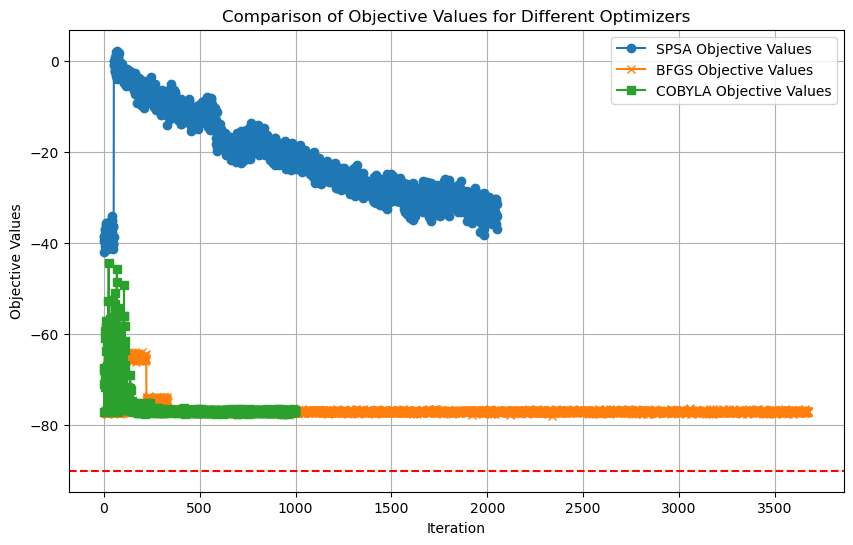

In [35]:
# Optimizer Sweep
# Extract the objective values for plotting
spsa_values = optimizer_data['SPSA']['obj_values']
bfgs_values = optimizer_data['BFGS']['obj_values']
cobyla_values = optimizer_data['COBYLA']['obj_values']

# Create a range for the x-axis (indices)
indices_spsa = range(len(spsa_values))
indices_bfgs = range(len(bfgs_values))
indices_cobyla = range(len(cobyla_values))

# Plot the values
plt.figure(figsize=(10, 6))
plt.plot(indices_spsa, spsa_values, label='SPSA Objective Values', marker='o')
plt.plot(indices_bfgs, bfgs_values, label='BFGS Objective Values', marker='x')
plt.plot(indices_cobyla, cobyla_values, label='COBYLA Objective Values', marker='s')

# Add labels, title, legend, and grid
plt.xlabel('Iteration')
plt.ylabel('Objective Values')
plt.title('Comparison of Objective Values for Different Optimizers')
plt.legend()
plt.grid()
plt.axhline(y=optimizer_data['exact_solution'], color='r', linestyle='--', label='Exact Solution')
plt.show()

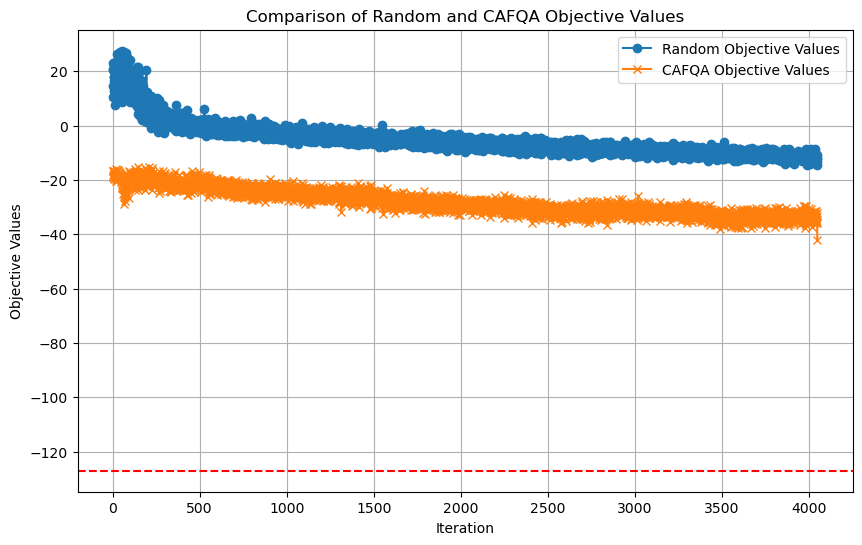

In [36]:
#SPSA Maxcut test

spsa_data = np.load( '../np_data/rep_sweep_2000_gens/spsa_test/2_layers/single_results_1.npy',allow_pickle=True).item()

# Extract the values from the dictionary
random_obj_values = spsa_data['Random_obj_values']
cafqa_obj_values = spsa_data['CAFQA_obj_values']

# Create a range for the x-axis (indices)
indices = range(len(random_obj_values))

# Plot the values
plt.figure(figsize=(10, 6))
plt.plot(indices, random_obj_values, label='Random Objective Values', marker='o')
plt.plot(indices, cafqa_obj_values, label='CAFQA Objective Values', marker='x')

# Add labels, title, legend, and grid
plt.xlabel('Iteration')
plt.ylabel('Objective Values')
plt.title('Comparison of Random and CAFQA Objective Values')
plt.legend()
plt.grid()
plt.axhline(y=spsa_data['Exact_solution_energy'], color='r', linestyle='--', label='Exact Solution Energy')
plt.show()

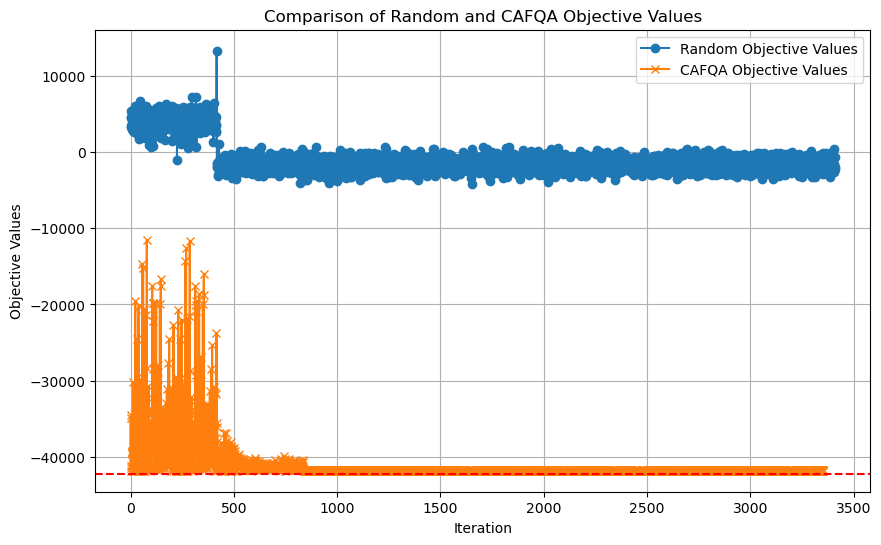

In [37]:
# COBYQA Knapsack Test

cobyqa_data = np.load('../np_data/knapsack/rep_sweep/COBYQA_test/13_qubits/COBYQA_results_single_1.npy',allow_pickle=True).item()

# Extract the values from the dictionary
random_obj_values = cobyqa_data['Random_objective_values']
cafqa_obj_values = cobyqa_data['CAFQA_objective_values']

# Plot the values
plt.figure(figsize=(10, 6))
plt.plot(range(len(random_obj_values)), random_obj_values, label='Random Objective Values', marker='o')
plt.plot(range(len(cafqa_obj_values)), cafqa_obj_values, label='CAFQA Objective Values', marker='x')

# Add labels, title, legend, and grid
plt.xlabel('Iteration')
plt.ylabel('Objective Values')
plt.title('Comparison of Random and CAFQA Objective Values')
plt.legend()
plt.grid()
plt.axhline(y=cobyqa_data['Exact_solution_energy'], color='r', linestyle='--', label='Exact Solution Energy')
plt.show()

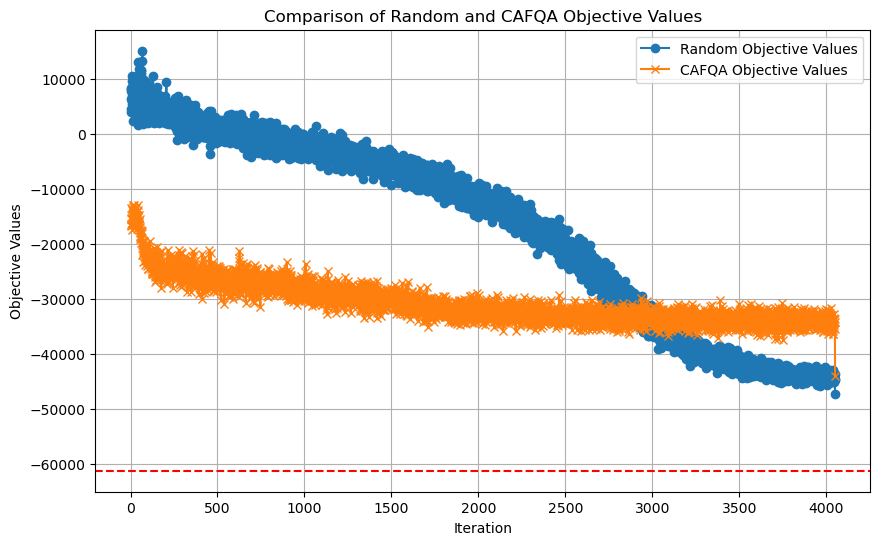

In [38]:
# SPSA Knapsack Test

spsa_knapsack_data = np.load('../np_data/knapsack/rep_sweep/SPSA_test/15_qubits/SPSA_results_single_1.npy',allow_pickle=True).item()

# Extract the values from the dictionary
random_obj_values = spsa_knapsack_data['Random_objective_values']
cafqa_obj_values = spsa_knapsack_data['CAFQA_objective_values']

# Plot the values
plt.figure(figsize=(10, 6))
plt.plot(range(len(random_obj_values)), random_obj_values, label='Random Objective Values', marker='o')
plt.plot(range(len(cafqa_obj_values)), cafqa_obj_values, label='CAFQA Objective Values', marker='x')

# Add labels, title, legend, and grid
plt.xlabel('Iteration')
plt.ylabel('Objective Values')
plt.title('Comparison of Random and CAFQA Objective Values')
plt.legend()
plt.grid()
plt.axhline(y=spsa_knapsack_data['Exact_solution_energy'], color='r', linestyle='--', label='Exact Solution Energy')
plt.show()

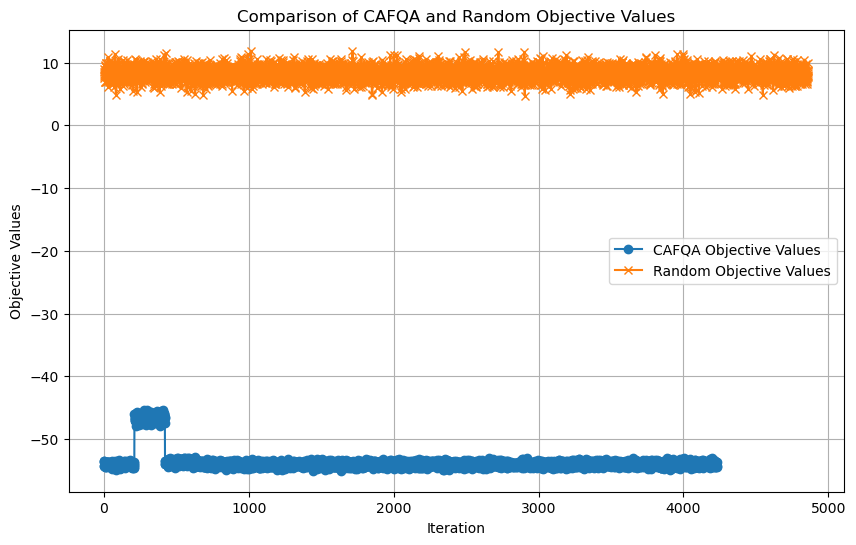

In [39]:
# BFGS 

bfgs_data = np.load( '../np_data/rep_sweep_2000_gens/BFGS_test/2_layers/single_results_1.npy',allow_pickle=True).item()

# Extract the values from the dictionary
cafqa_obj_values = bfgs_data['CAFQA_obj_values']
random_obj_values = bfgs_data['Random_obj_values']

# Create a range for the x-axis (indices)
indices = range(len(cafqa_obj_values))

# Plot the values
plt.figure(figsize=(10, 6))
plt.plot(range(len(cafqa_obj_values)), cafqa_obj_values, label='CAFQA Objective Values', marker='o')
plt.plot(range(len(random_obj_values)), random_obj_values, label='Random Objective Values', marker='x')

# Add labels, title, legend, and grid
plt.xlabel('Iteration')
plt.ylabel('Objective Values')
plt.title('Comparison of CAFQA and Random Objective Values')
plt.legend()
plt.grid()
plt.show()

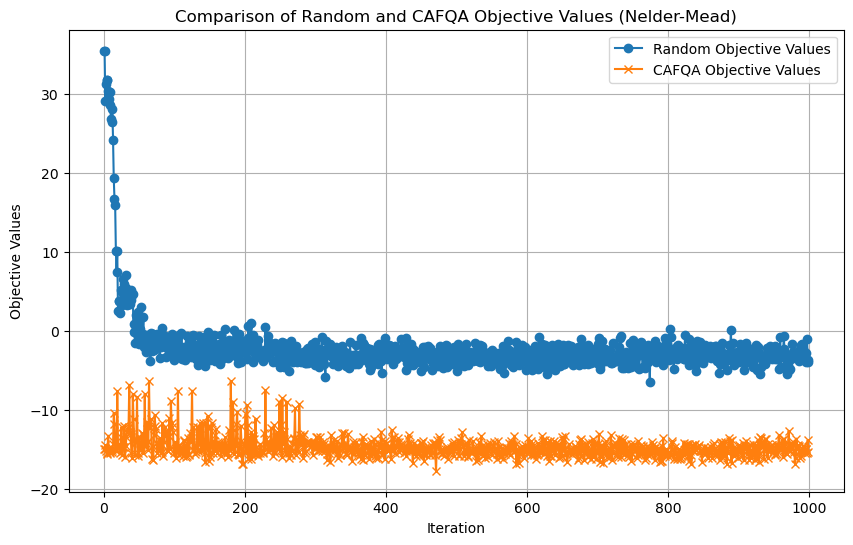

In [40]:
# Nelder-Mead
nm_data =  np.load( '../np_data/rep_sweep_2000_gens/NM_test/2_layers/12_qb_single_results_1.npy',allow_pickle=True).item()

# Extract the values from the dictionary
random_obj_values = nm_data['Random_obj_values']
cafqa_obj_values = nm_data['CAFQA_obj_values']

# Create a range for the x-axis (indices)
indices = range(len(random_obj_values))

# Plot the values
plt.figure(figsize=(10, 6))
plt.plot(range(len(random_obj_values)), random_obj_values, label='Random Objective Values', marker='o')
plt.plot(range(len(cafqa_obj_values)), cafqa_obj_values, label='CAFQA Objective Values', marker='x')

# Add labels, title, legend, and grid
plt.xlabel('Iteration')
plt.ylabel('Objective Values')
plt.title('Comparison of Random and CAFQA Objective Values (Nelder-Mead)')
plt.legend()
plt.grid()
plt.show()

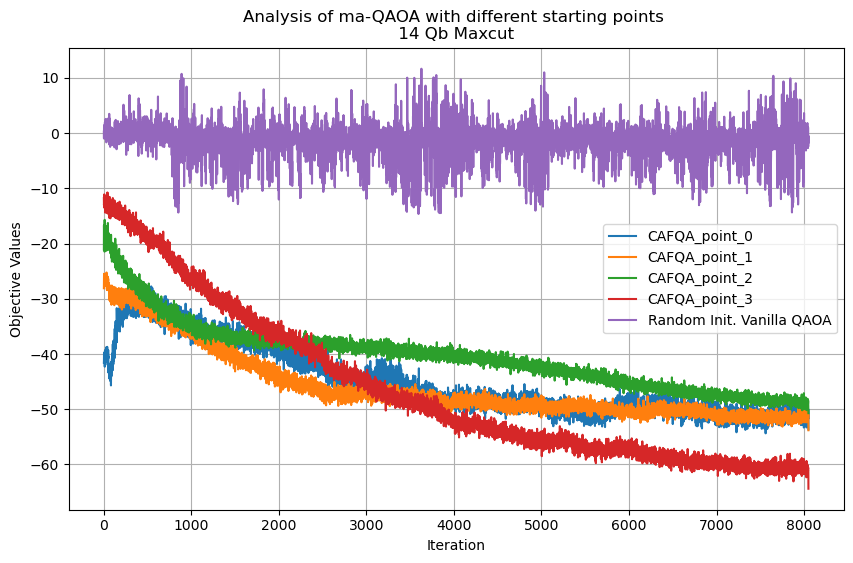

In [41]:
cafqa_diff_points_data =np.load( '../np_data/CAFQA_Analysis/Maxcut/14_qbs/SPSA_2_point_analysis_1.npy',allow_pickle=True).item()

# Extract obj_values from task_0 to task_4
tasks = [f'task_{i}' for i in range(4)]
obj_values = {task: cafqa_diff_points_data['Task_results'][task]['obj_values'] for task in tasks}

# Plot all obj_values on the same plot
plt.figure(figsize=(10, 6))
for i,(task, values) in enumerate(obj_values.items()):
    plt.plot(values, label=f'CAFQA_point_{i}')
plt.plot(cafqa_diff_points_data['Task_results']['Vanilla_task']['obj_values'], label='Random Init. Vanilla QAOA')
# Add labels, title, legend, and grid
plt.xlabel('Iteration')
plt.ylabel('Objective Values')
plt.title('Analysis of ma-QAOA with different starting points \n 14 Qb Maxcut ')
plt.legend()
plt.grid()
plt.show()

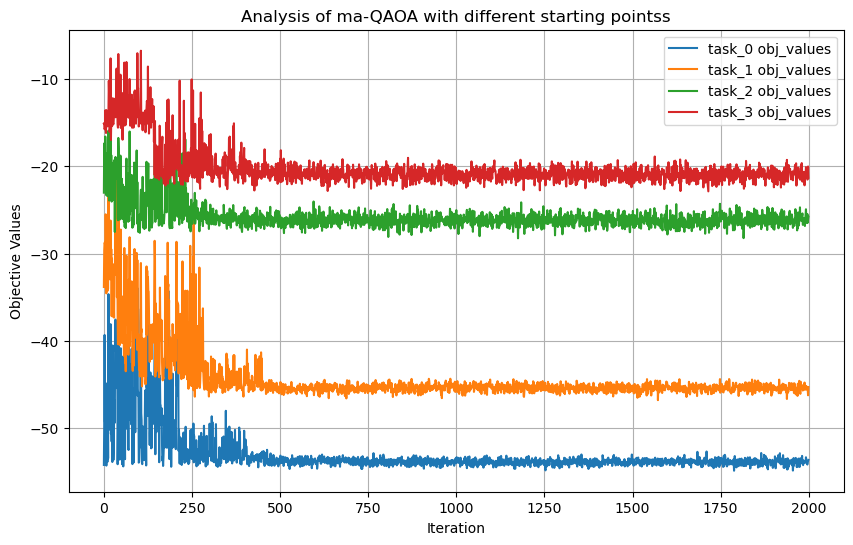

In [42]:
cafqa_diff_points_data_cobyla =np.load( '../np_data/CAFQA_Analysis/Maxcut/14_qbs/COBYLA_point_analysis_1.npy',allow_pickle=True).item()

# Extract obj_values from task_0 to task_4
tasks = [f'task_{i}' for i in range(4)]
obj_values = {task: cafqa_diff_points_data_cobyla['Task_results'][task]['obj_values'] for task in tasks}

# Plot all obj_values on the same plot
plt.figure(figsize=(10, 6))
for task, values in obj_values.items():
    plt.plot(values, label=f'{task} obj_values')

# Add labels, title, legend, and grid
plt.xlabel('Iteration')
plt.ylabel('Objective Values')
plt.title('Analysis of ma-QAOA with different starting pointss')
plt.legend()
plt.grid()
plt.show()

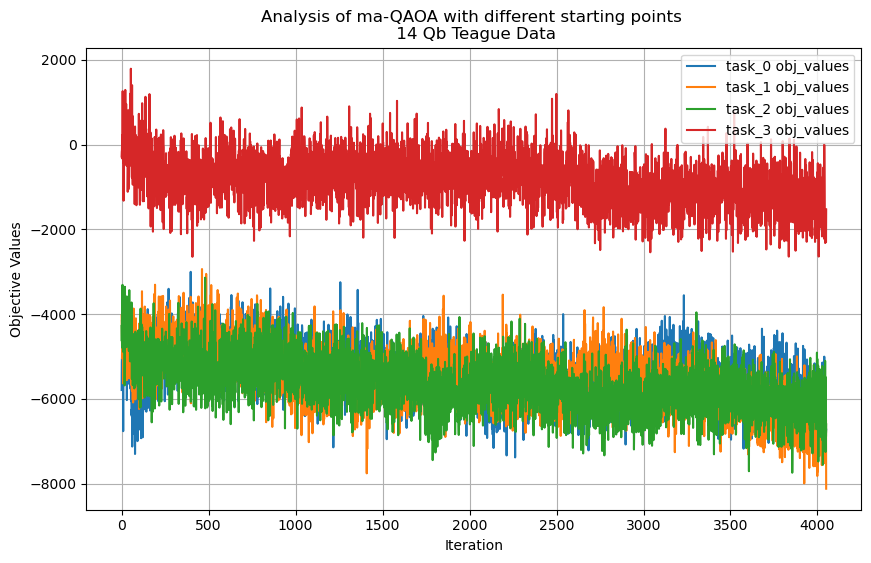

In [43]:
cafqa_diff_points_data_teague =np.load( '../np_data/CAFQA_Analysis/Teague_data/14_qbs/SPSA_point_analysis_1.npy',allow_pickle=True).item()

# Extract obj_values from task_0 to task_4
tasks = [f'task_{i}' for i in range(4)]
obj_values = {task: cafqa_diff_points_data_teague['Task_results'][task]['obj_values'] for task in tasks}

# Plot all obj_values on the same plot
plt.figure(figsize=(10, 6))
for task, values in obj_values.items():
    plt.plot(values, label=f'{task} obj_values')

# Add labels, title, legend, and grid
plt.xlabel('Iteration')
plt.ylabel('Objective Values')
plt.title('Analysis of ma-QAOA with different starting points \n 14 Qb Teague Data')
plt.legend()
plt.grid()
plt.show()

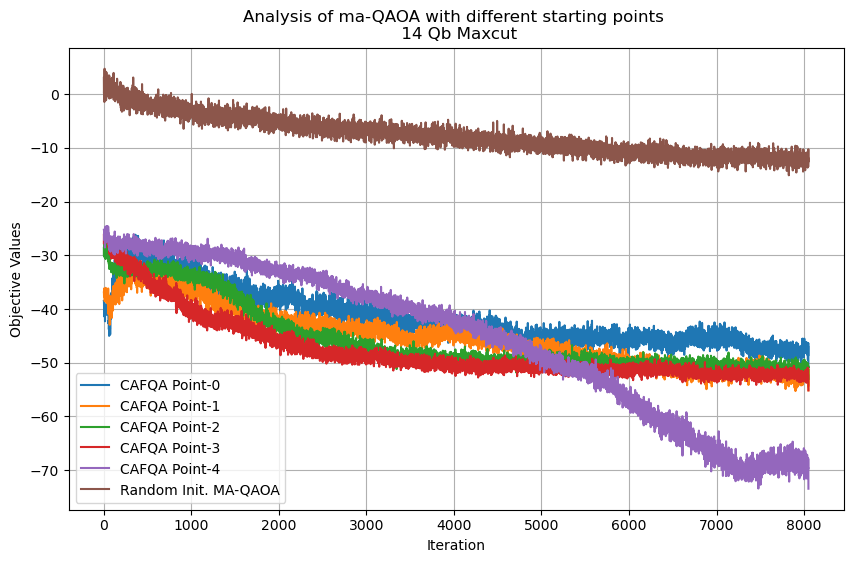

In [44]:
def plot_cafqa_analysis(file_path, title='Analysis of ma-QAOA with different starting points \n 14 Qb Maxcut'):

    cafqa_diff_points_data = np.load(file_path, allow_pickle=True).item()

    # Extract obj_values from task_0 to task_4
    tasks = [f'task_{i}' for i in range(5)]
    obj_values = {task: cafqa_diff_points_data['Task_results'][task]['obj_values'] for task in tasks}

    # Plot all obj_values on the same plot
    plt.figure(figsize=(10, 6))
    for i, (task, values) in enumerate(obj_values.items()):
        plt.plot(values, label=f'CAFQA Point-{i}')
    # plt.plot(cafqa_diff_points_data['Task_results']['Vanilla_task']['obj_values'], label='Random Init. Vanilla QAOA')
    plt.plot(cafqa_diff_points_data['Task_results']['Random_MA-QAOA']['obj_values'], label='Random Init. MA-QAOA')

    # Add labels, title, legend, and grid
    plt.xlabel('Iteration')
    plt.ylabel('Objective Values')
    plt.title(title)
    plt.legend()
    plt.grid()
    # plt.show()



plot_cafqa_analysis('../np_data/CAFQA_Analysis/Maxcut/14_qbs/SPSA_best_unique_5_point_analysis_1.npy', )

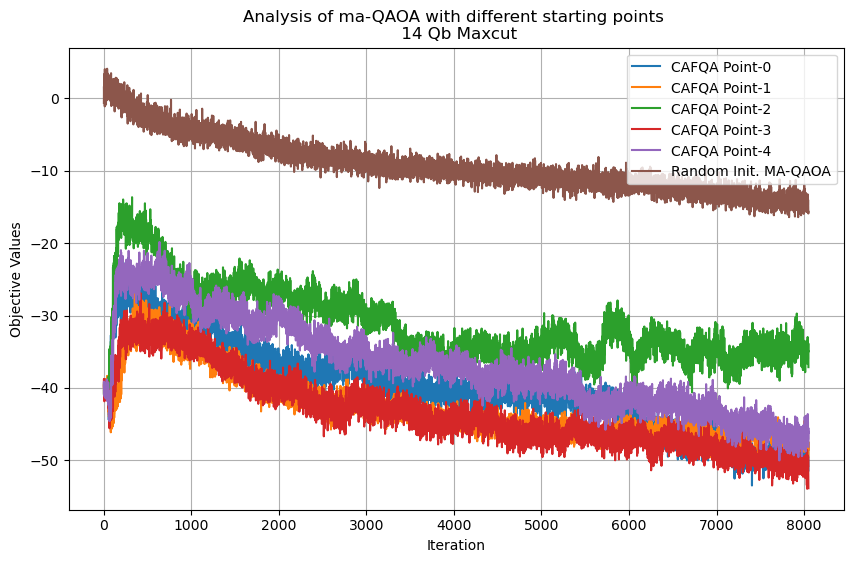

In [45]:
plot_cafqa_analysis( '../np_data/CAFQA_Analysis/Maxcut/14_qbs/SPSA_best_same_5_point_analysis_1.npy')
plt.show()

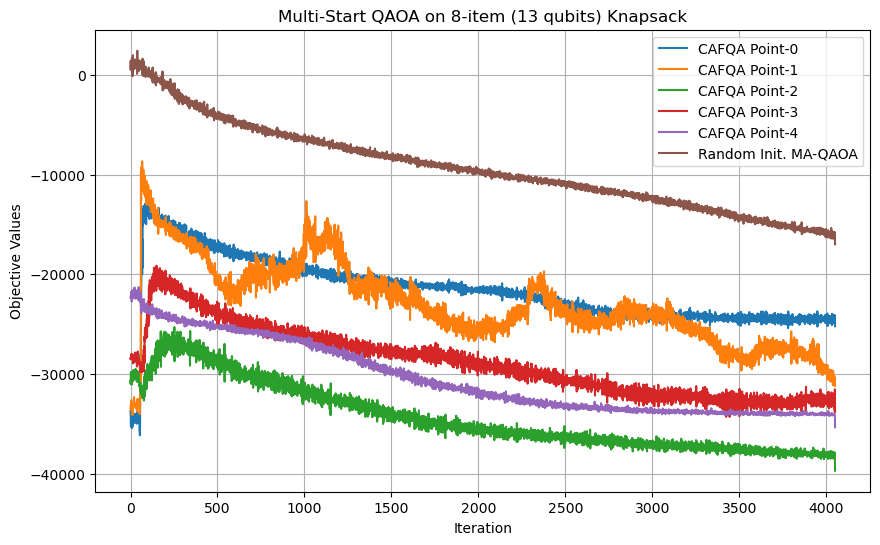

In [46]:
# Knapsack CAFQA Analysis
plot_cafqa_analysis('../np_data/CAFQA_Analysis/Knapsack/13_qbs/SPSA_best_spaced_5_point_analysis_1.npy',
                    title='Multi-Start QAOA on 8-item (13 qubits) Knapsack')

plt.savefig('../plots/knapsack_spsa_best_5_spaced.png', dpi=500, bbox_inches='tight')
plt.show()

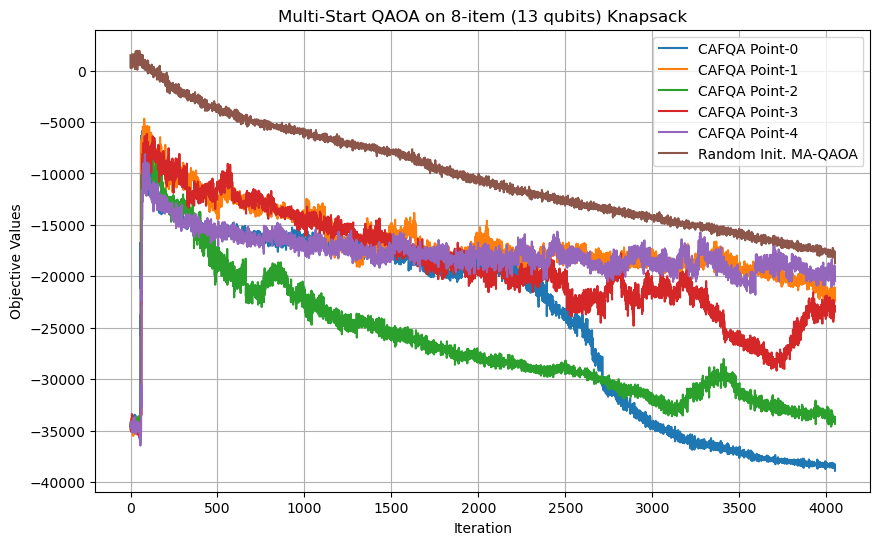

In [47]:
plot_cafqa_analysis('../np_data/CAFQA_Analysis/Knapsack/13_qbs/SPSA_best_same_5_point_analysis_1.npy',
                    title='Multi-Start QAOA on 8-item (13 qubits) Knapsack')

plt.savefig('../plots/knapsack_spsa_best_5_same.png', dpi=500, bbox_inches='tight')
plt.show()

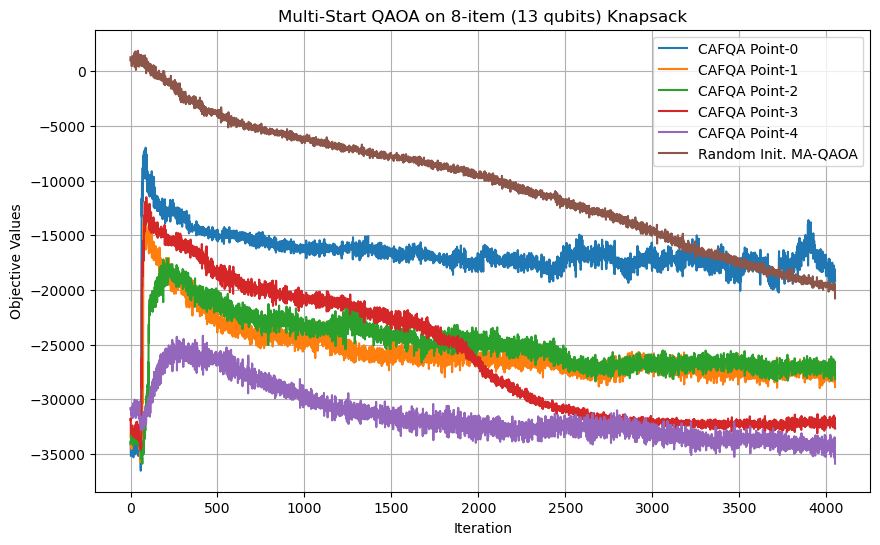

In [48]:
plot_cafqa_analysis('../np_data/CAFQA_Analysis/Knapsack/13_qbs/SPSA_best_unique_5_point_analysis_1.npy',
                    title='Multi-Start QAOA on 8-item (13 qubits) Knapsack')

plt.savefig('../plots/knapsack_spsa_best_unique_5.png', dpi=500, bbox_inches='tight')
plt.show()

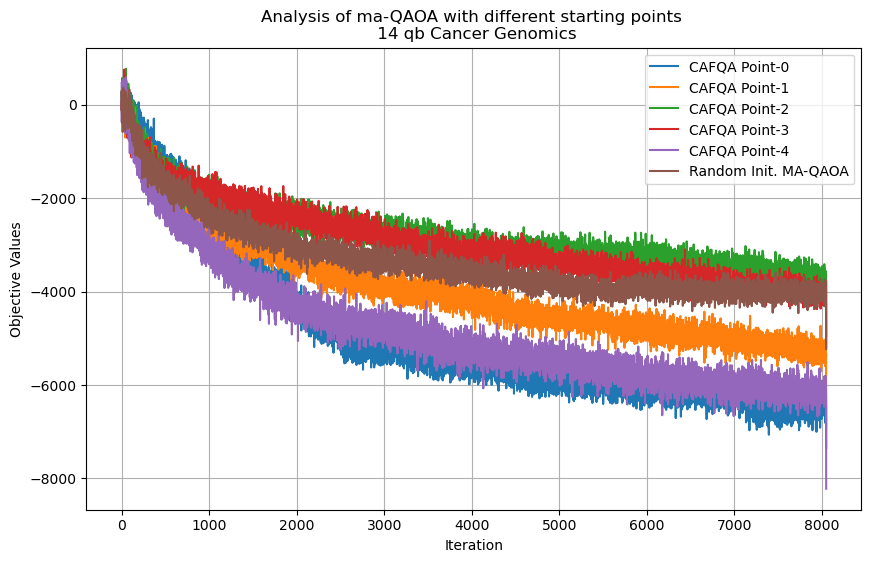

In [49]:
# Teague Data CAFQA Analysis
plot_cafqa_analysis('../np_data/CAFQA_Analysis/Teague_data/14_qbs/SPSA_best_same_5_point_analysis_1.npy',
                    title='Analysis of ma-QAOA with different starting points \n 14 qb Cancer Genomics')

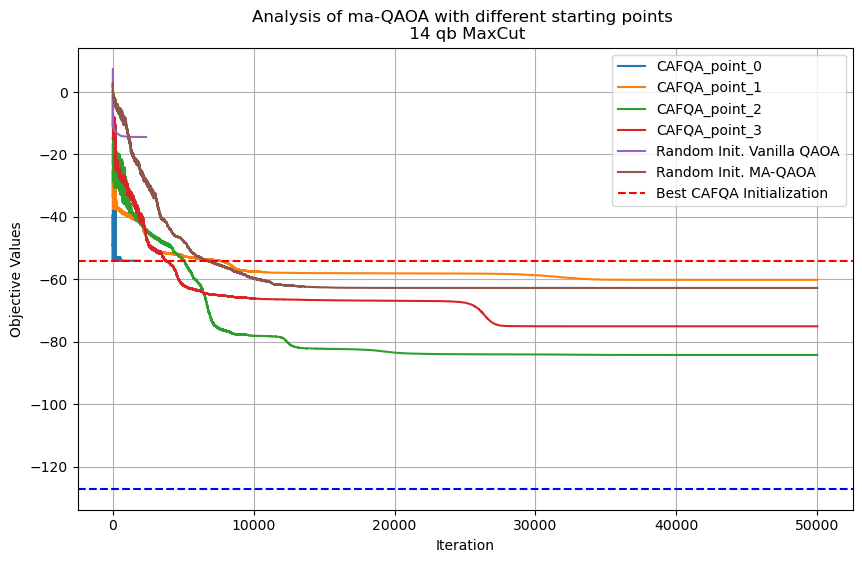

In [50]:
# plot_cafqa_analysis('../np_data/CAFQA_Analysis/14_qbs/Long_2_COBYLA_best_spaced_5_point_analysis_1.npy',
                    # title='Analysis of ma-QAOA with different starting points \n 14 qb MaxCut')


cafqa_diff_points_data = np.load('../np_data/CAFQA_Analysis/14_qbs/Long_2_COBYLA_best_spaced_5_point_analysis_1.npy', allow_pickle=True).item()

# Extract obj_values from task_0 to task_4
tasks = [f'task_{i}' for i in range(4)]
obj_values = {task: cafqa_diff_points_data['Task_results'][task]['obj_values'] for task in tasks}

# Plot all obj_values on the same plot
plt.figure(figsize=(10, 6))
for i, (task, values) in enumerate(obj_values.items()):
    plt.plot(values, label=f'CAFQA_point_{i}')
plt.plot(cafqa_diff_points_data['Task_results']['Vanilla_task']['obj_values'], label='Random Init. Vanilla QAOA')
plt.plot(cafqa_diff_points_data['Task_results']['Random_MA-QAOA']['obj_values'], label='Random Init. MA-QAOA')
best_cafqa_energy = cafqa_diff_points_data['CAFQA_initialization_energy']


# Add labels, title, legend, and grid
plt.xlabel('Iteration')
plt.ylabel('Objective Values')
plt.axhline(y=best_cafqa_energy, color='r', linestyle='--', label='Best CAFQA Initialization')
plt.legend()
plt.title('Analysis of ma-QAOA with different starting points \n 14 qb MaxCut')
plt.grid()
plt.axhline(y=-127, color='b', linestyle='--', label='Ground Energy')

plt.show()


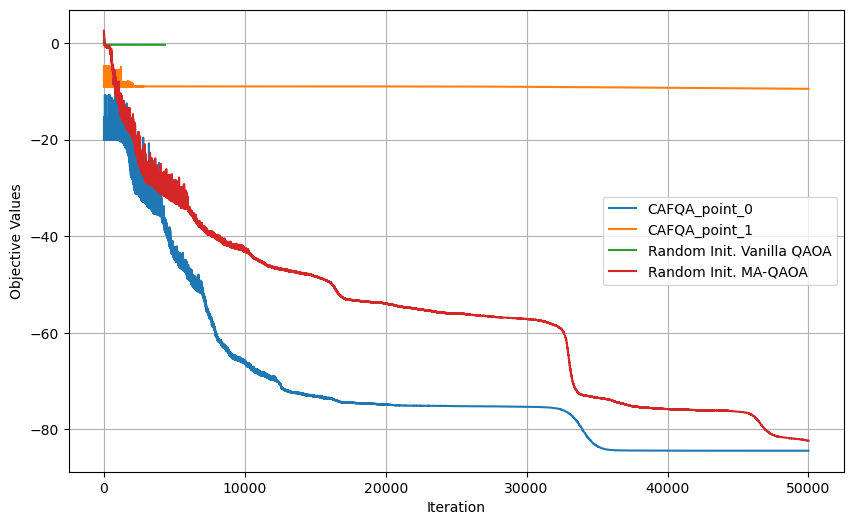

In [62]:
cafqa_diff_points_data = np.load('../np_data/CAFQA_Analysis/20_qbs/Long_COBYLA_best_spaced_5_point_analysis_1.npy', allow_pickle=True).item()

# Extract obj_values from task_0 to task_4
tasks = [f'task_{i}' for i in range(2)]
obj_values = {task: cafqa_diff_points_data['Task_results'][task]['obj_values'] for task in tasks}

# Plot all obj_values on the same plot
plt.figure(figsize=(10, 6))
for i, (task, values) in enumerate(obj_values.items()):
    plt.plot(values, label=f'CAFQA_point_{i}')
plt.plot(cafqa_diff_points_data['Task_results']['Vanilla_task']['obj_values'], label='Random Init. Vanilla QAOA')
plt.plot(cafqa_diff_points_data['Task_results']['Random_MA-QAOA']['obj_values'], label='Random Init. MA-QAOA')

# Add labels, title, legend, and grid
plt.xlabel('Iteration')
plt.ylabel('Objective Values')
plt.legend()
plt.grid()
# plt.xlim(0,30000)
plt.show()


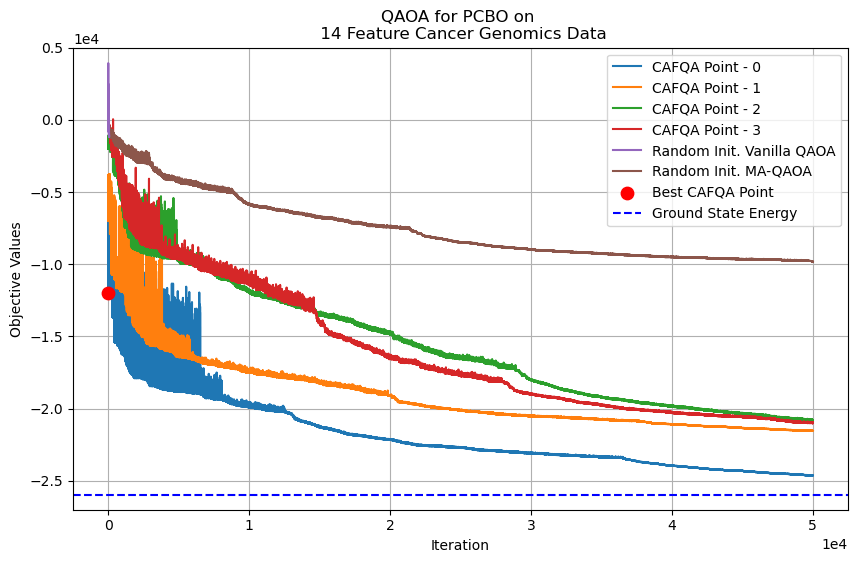

In [ ]:
# Teague Data 
# plot_cafqa_analysis('../np_data/CAFQA_Analysis/Teague_data/14_qbs/Long_COBYLA_best_spaced_5_point_analysis_1.npy',
#                     title='Analysis of ma-QAOA with different starting points \n 14 Feature Cancer Genomics Data')


cafqa_diff_points_data = np.load('../np_data/CAFQA_Analysis/Teague_data/14_qbs/Long_COBYLA_best_spaced_5_point_analysis_1.npy', allow_pickle=True).item()

# Extract obj_values from task_0 to task_4
tasks = [f'task_{i}' for i in range(4)]
obj_values = {task: cafqa_diff_points_data['Task_results'][task]['obj_values'] for task in tasks}

# Plot all obj_values on the same plot
plt.figure(figsize=(10, 6))
for i, (task, values) in enumerate(obj_values.items()):
    plt.plot(values, label=f'CAFQA Point - {i}')
plt.plot(cafqa_diff_points_data['Task_results']['Vanilla_task']['obj_values'], label='Random Init. Vanilla QAOA', zorder=7)
plt.plot(cafqa_diff_points_data['Task_results']['Random_MA-QAOA']['obj_values'], label='Random Init. MA-QAOA')

best_cafqa_energy = cafqa_diff_points_data['CAFQA_initialization_energy']

# Add labels, title, legend, and grid
plt.xlabel('Iteration')
plt.ylabel('Objective Values')
# plt.axhline(y=best_cafqa_energy, color='r', linestyle='--', label='Best CAFQA Initialization')
plt.scatter(0, obj_values['task_0'][0], color='red', s=80, zorder=5, label='Best CAFQA Point')
plt.title('QAOA for PCBO on \n 14 Feature Cancer Genomics Data')
plt.axhline(y=-26014.18, color='b', linestyle='--', label='Ground State Energy')
plt.ylim(-27000,5000)
plt.legend()
plt.grid()
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.savefig('../plots/teague_14_feature_cancer_genomics.png', dpi=500, bbox_inches='tight')
plt.show()

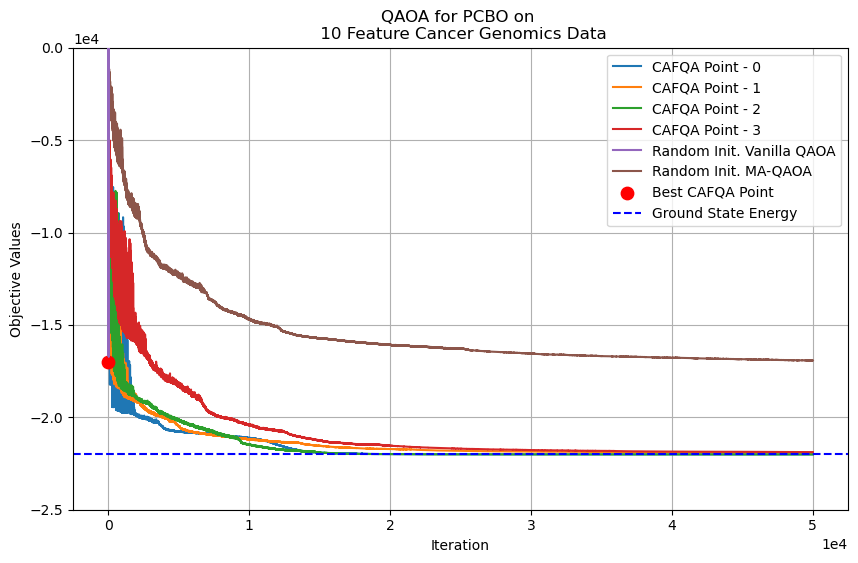

In [53]:
cafqa_diff_points_data = np.load('../np_data/CAFQA_Analysis/Teague_data/10_qbs/Long_COBYLA_best_spaced_5_point_analysis_1.npy', allow_pickle=True).item()

# Extract obj_values from task_0 to task_4
tasks = [f'task_{i}' for i in range(4)]
obj_values = {task: cafqa_diff_points_data['Task_results'][task]['obj_values'] for task in tasks}

# Plot all obj_values on the same plot
plt.figure(figsize=(10, 6))
for i, (task, values) in enumerate(obj_values.items()):
    plt.plot(values, label=f'CAFQA Point - {i}')
plt.plot(cafqa_diff_points_data['Task_results']['Vanilla_task']['obj_values'], label='Random Init. Vanilla QAOA',zorder=7)
plt.plot(cafqa_diff_points_data['Task_results']['Random_MA-QAOA']['obj_values'], label='Random Init. MA-QAOA')

best_cafqa_energy = cafqa_diff_points_data['CAFQA_initialization_energy']

# Add labels, title, legend, and grid
plt.xlabel('Iteration')
plt.ylabel('Objective Values')
# plt.axhline(y=best_cafqa_energy, color='r', linestyle='--', label='Best CAFQA Initialization')
plt.scatter(0, obj_values['task_0'][0], color='red', s=80, zorder=5, label='Best CAFQA Point')
plt.title('QAOA for PCBO on \n 10 Feature Cancer Genomics Data')
plt.axhline(y=-22010.37, color='b', linestyle='--', label='Ground State Energy')
plt.legend()
plt.grid()
plt.ylim(-25000,0)
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.ylabel('Objective Values')
plt.savefig('../plots/teague_10_feature_cancer_genomics.png', dpi=500, bbox_inches='tight')
plt.show()

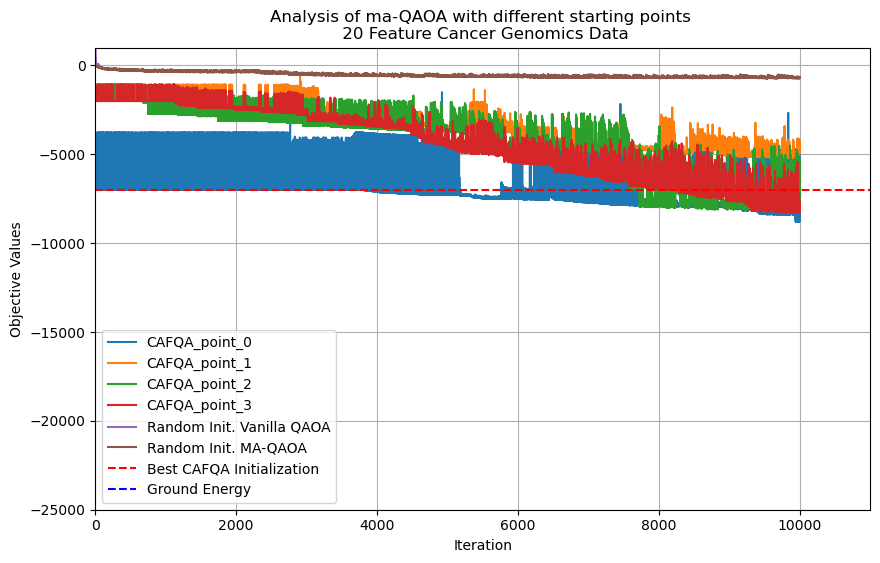

In [54]:
cafqa_diff_points_data = np.load('../np_data/CAFQA_Analysis/Teague_data/20_qbs/Long_5_COBYLA_best_spaced_4_point_analysis_1.npy', allow_pickle=True).item()

# Extract obj_values from task_0 to task_4
tasks = [f'task_{i}' for i in range(4)]
obj_values = {task: cafqa_diff_points_data['Task_results'][task]['obj_values'] for task in tasks}

# Plot all obj_values on the same plot
plt.figure(figsize=(10, 6))
for i, (task, values) in enumerate(obj_values.items()):
    plt.plot(values, label=f'CAFQA_point_{i}')
plt.plot(cafqa_diff_points_data['Task_results']['Vanilla_task']['obj_values'], label='Random Init. Vanilla QAOA')
plt.plot(cafqa_diff_points_data['Task_results']['Random_MA-QAOA']['obj_values'], label='Random Init. MA-QAOA')

best_cafqa_energy = cafqa_diff_points_data['CAFQA_initialization_energy']

# Add labels, title, legend, and grid
plt.xlabel('Iteration')
plt.ylabel('Objective Values')
plt.axhline(y=best_cafqa_energy, color='r', linestyle='--', label='Best CAFQA Initialization')
plt.title('Analysis of ma-QAOA with different starting points \n 20 Feature Cancer Genomics Data')
plt.axhline(y=-32023, color='b', linestyle='--', label='Ground Energy')
plt.legend()
plt.grid()
plt.xlim(0,11000)
plt.ylim(-25000,1000)


plt.show()

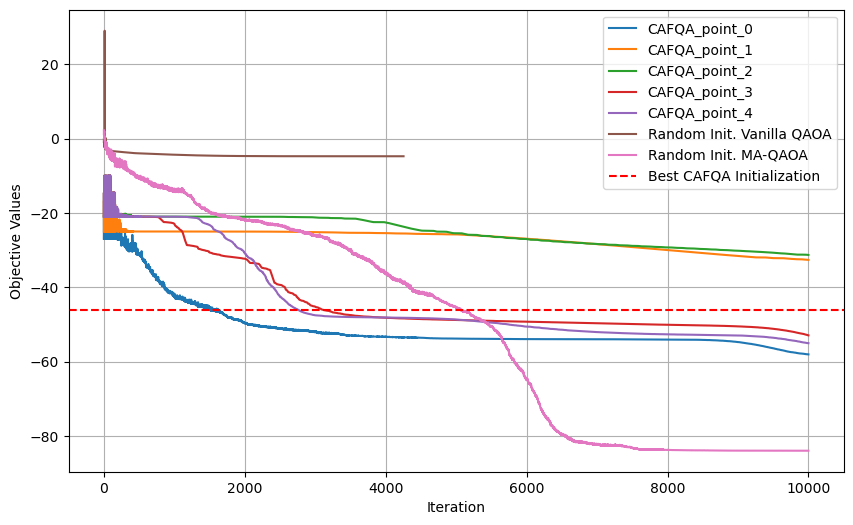

In [55]:
#Noisy Maxcut

cafqa_diff_points_data = np.load('../np_data/CAFQA_Analysis/12_qbs/Noisy_2_Long_COBYLA_best_spaced_5_point_analysis_1.npy', allow_pickle=True).item()

# Extract obj_values from task_0 to task_4
tasks = [f'task_{i}' for i in range(5)]
obj_values = {task: cafqa_diff_points_data['Task_results'][task]['obj_values'] for task in tasks}

# Plot all obj_values on the same plot
plt.figure(figsize=(10, 6))
for i, (task, values) in enumerate(obj_values.items()):
    plt.plot(values, label=f'CAFQA_point_{i}')
plt.plot(cafqa_diff_points_data['Task_results']['Vanilla_task']['obj_values'], label='Random Init. Vanilla QAOA')
plt.plot(cafqa_diff_points_data['Task_results']['Random_MA-QAOA']['obj_values'], label='Random Init. MA-QAOA')

best_cafqa_energy = cafqa_diff_points_data['CAFQA_initialization_energy']

# Add labels, title, legend, and grid
plt.xlabel('Iteration')
plt.ylabel('Objective Values')
plt.axhline(y=best_cafqa_energy, color='r', linestyle='--', label='Best CAFQA Initialization')
plt.legend()
plt.grid()

# plt.xlim(-10,1000)

plt.show()

In [56]:
cafqa_diff_points_data['Task_results']['task_0']

{'task_name': 'task_0',
 'result':  message: Maximum number of function evaluations has been exceeded.
  success: False
   status: 2
      fun: -58.0716294973189
        x: [-5.268e-03 -7.731e-01 ...  8.141e-03  4.721e+00]
     nfev: 10000
    maxcv: 0.0,
 'fitness_val': np.float64(-27.2345),
 'obj_values': [array(-27.),
  array(-20.56423228),
  array(-27.),
  array(-23.32241845),
  array(-27.),
  array(-23.32241845),
  array(-27.),
  array(-24.24181384),
  array(-15.96725534),
  array(-23.32241845),
  array(-20.56423228),
  array(-27.),
  array(-23.32241845),
  array(-24.24181384),
  array(-20.56423228),
  array(-20.56423228),
  array(-27.),
  array(-27.),
  array(-24.24181384),
  array(-23.32241845),
  array(-23.32241845),
  array(-20.56423228),
  array(-20.56423228),
  array(-19.64483689),
  array(-17.80604612),
  array(-13.20906918),
  array(-27.),
  array(-24.24181384),
  array(-20.56423228),
  array(-15.96725534),
  array(-13.20906918),
  array(-23.32241845),
  array(-17.80604612

## Approx Ratio

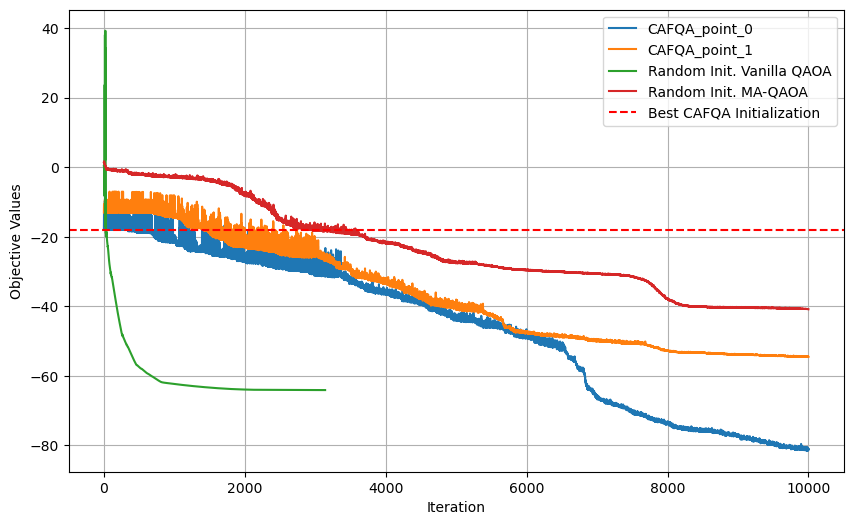

In [57]:
#Approx Ratio
 
cafqa_diff_points_data = np.load('../np_data/CAFQA_Analysis/Approx_Ratio/Maxcut/18_qbs/approx_ratio_Long__more_gens_COBYLA_best_spaced_5_point_analysis_2.npy', allow_pickle=True).item()

# Extract obj_values from task_0 to task_4
tasks = [f'task_{i}' for i in range(2)]
obj_values = {task: cafqa_diff_points_data['Task_results'][task]['obj_values'] for task in tasks}

# Plot all obj_values on the same plot
plt.figure(figsize=(10, 6))
for i, (task, values) in enumerate(obj_values.items()):
    plt.plot(values, label=f'CAFQA_point_{i}')
plt.plot(cafqa_diff_points_data['Task_results']['Vanilla_task']['obj_values'], label='Random Init. Vanilla QAOA')
plt.plot(cafqa_diff_points_data['Task_results']['Random_MA-QAOA']['obj_values'], label='Random Init. MA-QAOA')

best_cafqa_energy = cafqa_diff_points_data['CAFQA_initialization_energy']

# Add labels, title, legend, and grid
plt.xlabel('Iteration')
plt.ylabel('Objective Values')
plt.axhline(y=best_cafqa_energy, color='r', linestyle='--', label='Best CAFQA Initialization')
plt.legend()
plt.grid()

plt.show()

In [58]:
cafqa_diff_points_data['Task_results']['Random_MA-QAOA']['approx_ratio'],cafqa_diff_points_data['Task_results']['task_0']['approx_ratio']

(0.8698277886497057, 0.9096690802348342)

In [59]:
cafqa_diff_points_data['Task_results'].keys()

dict_keys(['task_0', 'task_1', 'Random_MA-QAOA', 'Vanilla_task'])